# Data Center Load Forecast & Rate Impact Model — Dominion (DOM) zone

**How to run:** fill in the **Settings** cell, then use **Kernel → Restart Kernel and Run All Cells** (Jupyter Lab) or **Kernel → Restart & Run All** (classic Jupyter).

1. **First time:** leave `SYNTHETIC = True`. The whole notebook then runs on **fake data**, so you can confirm everything works. You don't need an API key for this.
2. **Real run:** set `SYNTHETIC = False`, paste your EIA API key, fill in the three input CSVs (the *Check inputs* step creates blank templates), and run all again.

Charts appear under each step and are also saved as PNGs. Tables are saved as CSVs, plus one Excel workbook:

| | Fake data | Real data |
|---|---|---|
| Tables | `outputs_synthetic/tables/` | `outputs/tables/` |
| Charts | `outputs_synthetic/figures/` | `outputs/figures/` |
| Excel | `model_synthetic/` | `model/` |

All folders are created next to this notebook. Every assumption marked **VERIFY** in the Assumptions cell is a placeholder. Source each one before you use any results in a report.

## 0. Install packages
Installs into the same Python this notebook is running on. Run it once, then **restart the kernel** if anything was newly installed.

In [1]:
%pip install -q pandas numpy statsmodels holidays pyyaml matplotlib pyarrow openpyxl requests python-docx

Note: you may need to restart the kernel to use updated packages.


## Settings

In [2]:
SYNTHETIC = False        # True = fake test data (run this first).  False = real data.
EIA_API_KEY = "gscrjqeJALCQwscQq1CeCod7CbaQkgh3dN68qAy7"        # free key: https://www.eia.gov/opendata/register.php  (only needed when SYNTHETIC = False)

## Imports

In [3]:
import copy, os, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline
pd.set_option("display.width", 200, "display.max_columns", 30)

_nb_path = globals().get("__vsc_ipynb_file__")          # VS Code sets this to the notebook's path
ROOT = Path(_nb_path).parent if _nb_path else Path.cwd()  # always the folder this notebook is in
print("Working folder:", ROOT)

Working folder: /Users/opdime/Projects/dominionenergy_forecast


## Assumptions
Edit values here. Anything marked **VERIFY** is a placeholder that needs a source before you report it.

In [4]:
DEFAULT_CONFIG = {
    # --- report labels ---
    "project_name": "Data Center Load Growth in Virginia",
    "territory": "Dominion Energy Virginia (PJM DOM zone)",
    "balancing_authority": "PJM, DOM sub-region",
    "author": "Alexandre Ly",
    "course": "Independent Research",
    "repo_url": "github.com/alexly0329-cpu/dominionenergy_forecast",
    # --- run mode ---
    "synthetic_mode": False,              # true = use generated placeholder data (smoke tests only)
    "anchor_to_base_year": False,         # optional: rescale baseline to peak_base_2024_mw (only if you have a sourced value)
    "exclude_energized_from_overlay": True,  # energized MW already in dc_historical_connected_mw.csv
    # --- data sources ---
    "eia_api_key": "YOUR_EIA_KEY",        # free key: https://www.eia.gov/opendata/register.php
    "eia_route": "electricity/rto/region-sub-ba-data",   # EIA-930 sub-BA hourly demand
    "eia_facets": {"parent": ["PJM"], "subba": ["DOM"]},  # Dominion zone of PJM
    "load_start": "2019-01-01T00",
    "load_end": "2025-12-31T23",
    "weather_stations": {                 # name: [lat, lon, population weight]  VERIFY weights
        "IAD_NoVA": [38.95, -77.45, 0.45],
        "RIC_Richmond": [37.51, -77.32, 0.30],
        "ORF_Norfolk": [36.90, -76.19, 0.25],
    },
    # --- horizon / baseline ---
    "base_year": 2024,
    "horizon_start": 2025,
    "horizon_end": 2035,
    "train_end_year": 2023,
    "test_start_year": 2024,
    "degree_day_base_f": 65,
    "peak_base_2024_mw": None,            # only used if anchor_to_base_year is True; enter a sourced value
    "energy_base_2024_gwh": None,         # only used if anchor_to_base_year is True; enter a sourced value
    # --- data center assumptions ---
    "dc_load_factor": 0.80,               # assumption; sensitivity tests 0.50 (LBNL avg. capacity utilization) to 0.90
    "dc_pue_default": 1.30,               # grid MW = IT MW x PUE when only IT MW is reported
    "stage_prob": {                       # VERIFY probability a project at this stage gets built
        "low":  {"announced": 0.10, "zoned": 0.25, "interconnection_request": 0.35, "esa_signed": 0.65, "construction": 0.85, "energized": 1.0},
        "base": {"announced": 0.20, "zoned": 0.40, "interconnection_request": 0.50, "esa_signed": 0.80, "construction": 0.92, "energized": 1.0},
        "high": {"announced": 0.35, "zoned": 0.55, "interconnection_request": 0.65, "esa_signed": 0.90, "construction": 0.97, "energized": 1.0},
    },
    "stage_delay_median_yrs": {"announced": 2.0, "zoned": 1.5, "interconnection_request": 1.5, "esa_signed": 1.0, "construction": 0.5, "energized": 0.0},
    "stage_ramp_yrs": {"announced": 4, "zoned": 4, "interconnection_request": 3, "esa_signed": 3, "construction": 3, "energized": 1},
    "stage_delay_sigma": 0.5,
    "unannounced_mw_per_yr": {"low": 0, "base": 150, "high": 400},
    "unannounced_sd": 100,
    "mc_draws": 5000,
    "mc_correlated": True,                # add a shared shock so projects succeed / slip together
    "mc_common_logit_sd": 0.75,           # assumption: spread of the shared build-probability shock (logit scale)
    "mc_common_delay_sd": 0.40,           # assumption: spread of the shared delay multiplier (log scale)
    "seed": 42,
    # --- supply / capital ---
    "fpr": 0.926,                         # PJM 2027/28 Forecast Pool Requirement: accredited MW needed per MW of peak
    "resource_shares": {"gas_cc": 0.47, "storage_4h": 0.28, "solar": 0.11, "smr_nuclear": 0.14},  # Dominion 2024 IRP additions x ELCC
    "elcc": {"gas_cc": 0.74, "storage_4h": 0.58, "solar": 0.08, "smr_nuclear": 0.95},          # PJM 2027/28 ELCC class ratings
    "capex_per_kw": {"gas_cc": 2200, "storage_4h": 1580, "solar": 1379, "smr_nuclear": 9314},  # 2024$/kW: GridLab (gas), EIA AEO2025 (others)
    "fom_per_kw_yr": {"gas_cc": 12.31, "storage_4h": 40.62, "solar": 22.91, "smr_nuclear": 123.88},  # EIA AEO2025, 2024$
    "book_life_yrs": {"gas_cc": 30, "storage_4h": 15, "solar": 30, "smr_nuclear": 60, "td": 45},
    "td_capex_per_kw_peak": 400,          # VERIFY transmission & distribution $/kW of new peak
    "marginal_energy_cost_per_mwh": 50.73,  # PJM 2025 load-weighted avg real-time LMP (Monitoring Analytics)
    "inflation": 0.025,
    # --- regulatory finance ---
    "equity_share": 0.52035,              # SCC final order PUR-2025-00058 (Nov. 2025)
    "roe": 0.098,                         # SCC Nov 2025 biennial review order
    "tax_rate": 0.257,                    # 21% federal + 6% Virginia (net of federal deduction)
    "cost_of_debt": 0.05,                 # assumption
    "ciac_share": 0.05,                   # share of capex paid upfront by customers (status quo)
    "tariff_ciac_share": 0.25,            # with a large-load tariff
    "retail_rate_2024_c_kwh": 10.62,      # Virginia avg. retail price 2024, all sectors (EIA state profile)
    # --- stranded-asset / tariff test ---
    "stranded_year": 2030,
    "stranded_share": 0.25,
    "gs5_min_td": 0.85,                   # GS-5 minimum: 85% of contracted T&D demand
    "gs5_min_gen": 0.60,                  # GS-5 minimum: 60% of contracted generation demand
    # --- reporting ---
    "report_years": [2030, 2035],
}

## Constants & helper functions

In [5]:
STAGES = ["announced", "zoned", "interconnection_request", "esa_signed", "construction", "energized"]
STAGE_SYNONYMS = {
    "announced": "announced", "proposed": "announced", "planned": "announced", "rumored": "announced",
    "zoned": "zoned", "approved": "zoned", "rezoned": "zoned", "entitled": "zoned", "permitted": "zoned",
    "interconnection_request": "interconnection_request", "interconnection request": "interconnection_request",
    "under study": "interconnection_request", "under_study": "interconnection_request", "queue": "interconnection_request",
    "esa_signed": "esa_signed", "esa signed": "esa_signed", "contracted": "esa_signed", "esa": "esa_signed",
    "construction": "construction", "under construction": "construction", "under_construction": "construction",
    "energized": "energized", "operational": "energized", "online": "energized", "in service": "energized",
}
TECHS = ["gas_cc", "storage_4h", "solar", "smr_nuclear"]
LABEL = {"announced": "Announced", "zoned": "Zoned", "interconnection_request": "Interconnection request",
         "esa_signed": "ESA signed", "construction": "Under construction", "energized": "Energized",
         "gas_cc": "Gas combined cycle", "storage_4h": "4-hour storage", "solar": "Solar (tracking)",
         "smr_nuclear": "Small modular reactor", "td": "Transmission & distribution",
         "low": "Low", "base": "Base", "high": "High", "mc_p5": "Monte Carlo 5th pct.", "mc_p50": "Monte Carlo median",
         "mc_p95": "Monte Carlo 95th pct.", "base_stranded": "Base + stranding, no tariff",
         "base_stranded_tariff": "Base + stranding, GS-5 tariff"}
PIPELINE_COLS = ["project_id", "campus_name", "developer", "tenant", "county", "state", "capacity_mw_it",
                 "capacity_mw_grid", "stage", "announced_date", "expected_cod", "source_url", "source_quote",
                 "source_date", "duplicate_of", "confidence", "notes"]


P = {}


def setup_paths(c):
    sfx = "_synthetic" if c["synthetic_mode"] else ""
    P.update({
        "raw": ROOT / f"data{sfx}/raw", "interim": ROOT / f"data{sfx}/interim", "proc": ROOT / f"data{sfx}/processed",
        "fig": ROOT / f"outputs{sfx}/figures", "tab": ROOT / f"outputs{sfx}/tables", "model": ROOT / f"model{sfx}",
    })
    for d in P.values():
        d.mkdir(parents=True, exist_ok=True)


def years(c):
    return list(range(c["horizon_start"], c["horizon_end"] + 1))


def savefig(name, title=None, source=None):
    if title:
        plt.title(title)
    if source:
        plt.figtext(0.01, 0.005, f"Source: {source}", fontsize=7, ha="left")
    plt.tight_layout()
    plt.savefig(P["fig"] / name, dpi=200)
    plt.show()          # display inline in the notebook


def mape(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    m = (y != 0) & ~np.isnan(y) & ~np.isnan(yhat)
    return float(np.mean(np.abs(yhat[m] - y[m]) / y[m]) * 100)


def ramp_fraction(year, cod, ramp_yrs):
    return float(np.clip((year + 1 - cod) / max(ramp_yrs, 1e-6), 0, 1))


def normalize_stage(s):
    if pd.isna(s):
        return None
    key = str(s).strip().lower().replace("-", "_")
    return STAGE_SYNONYMS.get(key, STAGE_SYNONYMS.get(key.replace("_", " ")))


def load_dc_series(years_needed):
    """Cumulative connected DC MW, reindexed to all needed years, interpolated and linearly extrapolated."""
    dc = pd.read_csv(P["raw"] / "dc_historical_connected_mw.csv")[["year", "dc_connected_mw"]]
    dc = dc.dropna().astype({"year": int, "dc_connected_mw": float}).drop_duplicates("year").set_index("year").sort_index()
    if len(dc) < 2:
        raise SystemExit("dc_historical_connected_mw.csv needs at least 2 years of data")
    full = pd.Index(range(min(dc.index.min(), min(years_needed)), max(dc.index.max(), max(years_needed)) + 1), name="year")
    s = dc.dc_connected_mw.reindex(full).interpolate(limit_direction="both")
    slope = (dc.dc_connected_mw.iloc[-1] - dc.dc_connected_mw.iloc[0]) / max(dc.index[-1] - dc.index[0], 1)
    for y in full:
        if y > dc.index.max():
            s[y] = dc.dc_connected_mw.iloc[-1] + slope * (y - dc.index.max())
        if y < dc.index.min():
            s[y] = max(dc.dc_connected_mw.iloc[0] - slope * (dc.index.min() - y), 0)
    return s.clip(lower=0)


def write_templates():
    """Create empty input templates for any missing real-data file."""
    made = []
    p = P["raw"] / "dc_historical_connected_mw.csv"
    if not p.exists():
        pd.DataFrame({"year": range(2018, 2026), "dc_connected_mw": np.nan, "source": "VERIFY", "source_url": "VERIFY",
                      "note": "cumulative connected data center MW at year end"}).to_csv(p, index=False)
        made.append(p)
    p = P["proc"] / "pipeline.csv"
    if not p.exists():
        pd.DataFrame([dict(project_id="P000", campus_name="EXAMPLE Campus (delete me)", developer="ExampleDev", tenant="",
                           county="Loudoun", state="VA", capacity_mw_it=np.nan, capacity_mw_grid=300, stage="zoned",
                           announced_date="2024-03-01", expected_cod=2028, source_url="VERIFY", source_quote="",
                           source_date="2024-03-01", duplicate_of="", confidence="medium", notes="")])[PIPELINE_COLS].to_csv(p, index=False)
        made.append(p)
    p = P["raw"] / "external_forecasts.csv"
    if not p.exists():
        pd.DataFrame(columns=["source", "vintage", "metric", "zone", "year", "value_mw", "url", "note"]).to_csv(p, index=False)
        made.append(p)
    for m in made:
        print(f"  template created: {m.relative_to(ROOT)} — fill it in")


def load_config():
    c = copy.deepcopy(DEFAULT_CONFIG)
    c["synthetic_mode"] = bool(SYNTHETIC)
    key = EIA_API_KEY or os.environ.get("EIA_API_KEY", "")
    if key:
        c["eia_api_key"] = key
    return c


c = load_config()
setup_paths(c)
print("Mode:", "SYNTHETIC (fake data)" if c["synthetic_mode"] else "REAL data", "| data folder:", P["raw"].parent)

Mode: REAL data | data folder: /Users/opdime/Projects/dominionenergy_forecast/data


## 1. Fake data (only when `SYNTHETIC = True`)

In [6]:
def step_synthetic(c):
    rng = np.random.default_rng(1)
    idx = pd.date_range(pd.Timestamp(c["load_start"][:10]), pd.Timestamp(c["load_end"][:10]) + pd.Timedelta(hours=23), freq="h")
    doy, hr, t = idx.dayofyear.values, idx.hour.values, (idx - idx[0]).days.values / 365.25
    temp_f = 57 + 22 * np.sin(2 * np.pi * (doy - 110) / 365) + 8 * np.sin(2 * np.pi * (hr - 9) / 24) + rng.normal(0, 4, len(idx))
    cdd, hdd = np.clip(temp_f - 65, 0, None), np.clip(65 - temp_f, 0, None)
    dc = 1500 + 650 * (idx.year.values - 2018)
    load = (11000 + 60 * cdd + 1.5 * cdd ** 2 + 35 * hdd + 0.6 * hdd ** 2 + 110 * t + c["dc_load_factor"] * dc
            + 1500 * np.sin(2 * np.pi * (hr - 17) / 24) + rng.normal(0, 300, len(idx)))
    pidx = pd.Index(idx, name="period")
    pd.DataFrame({"load_mw": load}, index=pidx).to_parquet(P["raw"] / "load_hourly.parquet")
    pd.DataFrame({"temp_c": (temp_f - 32) * 5 / 9, "temp_f": temp_f}, index=pidx).to_parquet(P["raw"] / "weather_hourly.parquet")
    yrs = range(2018, 2026)
    pd.DataFrame({"year": yrs, "dc_connected_mw": [1500 + 650 * (y - 2018) for y in yrs], "source": "SYNTHETIC",
                  "source_url": "", "note": "SYNTHETIC"}).to_csv(P["raw"] / "dc_historical_connected_mw.csv", index=False)
    rows = []
    for i in range(40):
        st = rng.choice(STAGES, p=[0.3, 0.2, 0.2, 0.15, 0.1, 0.05])
        rows.append(dict(project_id=f"S{i:03d}", campus_name=f"SYNTHETIC Campus {i}", developer=f"Dev{rng.integers(1, 8)}",
                         tenant="", county=rng.choice(["Loudoun", "Prince William", "Fauquier", "Henrico"]), state="VA",
                         capacity_mw_it=np.nan, capacity_mw_grid=int(rng.choice([100, 200, 300, 500, 800, 1000])),
                         stage=st, announced_date="2024-01-01", expected_cod=int(rng.integers(2026, 2032)),
                         source_url="SYNTHETIC", source_quote="SYNTHETIC", source_date="2024-01-01", duplicate_of="",
                         confidence="low", notes="SYNTHETIC"))
    pd.DataFrame(rows)[PIPELINE_COLS].to_csv(P["proc"] / "pipeline.csv", index=False)
    pd.DataFrame([{"source": "SYNTHETIC official", "vintage": 2025, "metric": "summer_peak", "zone": "DOM", "year": y,
                   "value_mw": v, "url": "", "note": "SYNTHETIC"} for y, v in [(2030, 27000), (2035, 33000)]]
                 ).to_csv(P["raw"] / "external_forecasts.csv", index=False)
    print(f"SYNTHETIC data written to {P['raw'].parent.relative_to(ROOT)}/ — never use these outputs in the report")


if c["synthetic_mode"]:
    step_synthetic(c)
else:
    print("Real-data mode — skipping fake data generation")

Real-data mode — skipping fake data generation


In [7]:
# --- Add Dominion-reported ESA capacity not already in pipeline.csv ---
ESA_TOTAL_MW = 12000        # "12.0 GW under ESAs" — Dominion Q2 2026 slides. VERIFY wording/definition.
ALREADY_LISTED_MW = 2708    # ESA-backed MW already in pipeline.csv (your 7 construction projects) — adjust if needed
COD_YEARS = [2027, 2028, 2029, 2030, 2031]   # spread of start dates; use Dominion's stated timing if the slides give it
CHUNK_MW = 300
SOURCE_URL = ("https://www.investing.com/news/company-news/"
              "dominion-q2-2026-slides-data-centers-surge-offshore-wind-81-done-93CH-4828982")

remaining = ESA_TOTAL_MW - ALREADY_LISTED_MW
per_year = remaining / len(COD_YEARS)
rows, i = [], 0
for y in COD_YEARS:
    n = max(int(round(per_year / CHUNK_MW)), 1)
    for k in range(n):
        i += 1
        rows.append(dict(
            project_id=f"AGG-ESA-{i:03d}", campus_name=f"Dominion ESA aggregate (unnamed) {y}-{k+1}",
            developer="", tenant="", county="", state="VA", capacity_mw_it=np.nan,
            capacity_mw_grid=round(per_year / n, 1), stage="esa_signed", announced_date="2026-07-31",
            expected_cod=y, source_url=SOURCE_URL, source_quote="12.0 GW under electric service agreements",
            source_date="2026-07-31", duplicate_of="", confidence="medium",
            notes=f"Aggregate: Dominion-reported ESA MW ({ESA_TOTAL_MW}) minus individually listed ESA-backed MW "
                  f"({ALREADY_LISTED_MW}); split into ~{CHUNK_MW} MW chunks so Monte Carlo is not all-or-nothing"))

pipe = pd.read_csv(P["proc"] / "pipeline.csv")
pipe = pipe[~pipe.project_id.astype(str).str.startswith("AGG-ESA")]          # rerun-safe
out = pd.concat([pipe, pd.DataFrame(rows)[PIPELINE_COLS]], ignore_index=True)
out.to_csv(P["proc"] / "pipeline.csv", index=False)
print(f"added {len(rows)} aggregate ESA rows totaling {remaining:,.0f} MW → pipeline now {len(out)} rows")

added 30 aggregate ESA rows totaling 9,292 MW → pipeline now 46 rows


## 2. Check inputs
This step validates the assumptions and your input files. If a real input file is missing, it creates a blank template for you to fill in. The notebook stops here if anything needs fixing.

In [8]:
def step_check(c):
    ok = True

    def fail(msg):
        nonlocal ok
        ok = False
        print("  ✗", msg)

    def warn(msg): print("  !", msg)
    def good(msg): print("  ✓", msg)

    print(f"[mode] {'SYNTHETIC (fake data)' if c['synthetic_mode'] else 'REAL data'}")
    if not c["synthetic_mode"]:
        write_templates()

    print("[config]")
    if not c["synthetic_mode"] and c["eia_api_key"] in ("", "YOUR_EIA_KEY"):
        fail("eia_api_key not set in config.yaml (or set SYNTHETIC = True)")
    else:
        good("EIA key present or synthetic mode")
    if abs(sum(c["resource_shares"].values()) - 1) > 1e-6:
        fail(f"resource_shares sum to {sum(c['resource_shares'].values()):.3f}, must be 1.0")
    else:
        good("resource_shares sum to 1")
    for k in c["resource_shares"]:
        for tbl in ["elcc", "capex_per_kw", "fom_per_kw_yr", "book_life_yrs"]:
            if k not in c[tbl]:
                fail(f"{tbl} missing technology '{k}'")
    for tbl in ["stage_delay_median_yrs", "stage_ramp_yrs"] + [f"stage_prob.{s}" for s in ["low", "base", "high"]]:
        d = c["stage_prob"][tbl.split(".")[1]] if "." in tbl else c[tbl]
        missing = [s for s in STAGES if s not in d]
        if missing:
            fail(f"{tbl} missing {missing}")
    if c["train_end_year"] >= c["test_start_year"]:
        fail("train_end_year must be before test_start_year")

    print("[load & weather]")
    for f in ["load_hourly.parquet", "weather_hourly.parquet"]:
        if (P["raw"] / f).exists():
            good(f"{f} present")
        else:
            warn(f"{f} not downloaded yet — the `ingest` step creates it")

    print("[dc historical series]")
    p = P["raw"] / "dc_historical_connected_mw.csv"
    d = pd.read_csv(p)
    if "dc_connected_mw" not in d or d.dc_connected_mw.dropna().shape[0] < 2:
        fail("dc_historical_connected_mw.csv needs >=2 rows with dc_connected_mw")
    else:
        if (d.dc_connected_mw.dropna().diff().dropna() < 0).any():
            warn("series falls in some year — cumulative MW should not decrease")
        good(f"{d.dc_connected_mw.notna().sum()} years of DC series")
    if "source" in d and d.source.astype(str).str.contains("VERIFY").any():
        warn("DC series still contains VERIFY placeholders")

    print("[pipeline]")
    pipe = pd.read_csv(P["proc"] / "pipeline.csv")
    missing_cols = [col for col in ["project_id", "campus_name", "developer", "county", "capacity_mw_it",
                                    "capacity_mw_grid", "stage", "announced_date", "expected_cod", "source_url",
                                    "duplicate_of"] if col not in pipe.columns]
    if missing_cols:
        fail(f"pipeline.csv missing columns {missing_cols}")
    else:
        pipe = pipe[~pipe.campus_name.astype(str).str.contains("EXAMPLE", case=False, na=False)]
        if len(pipe) == 0:
            fail("pipeline.csv has no real rows yet")
        elif len(pipe) < 30:
            warn(f"only {len(pipe)} non-example pipeline rows (rubric needs >=30)")
        else:
            good(f"{len(pipe)} pipeline rows")
        bad = pipe[pipe.stage.map(normalize_stage).isna()]
        if len(bad):
            fail(f"unrecognized stage values {bad.stage.unique().tolist()} (rows {bad.project_id.tolist()}). Allowed: {STAGES}")
        elif len(pipe):
            good("all stages recognized")
        nocap = pipe[pd.to_numeric(pipe.capacity_mw_grid, errors="coerce").isna() & pd.to_numeric(pipe.capacity_mw_it, errors="coerce").isna()]
        if len(nocap):
            fail(f"rows with no capacity: {nocap.project_id.tolist()}")
        if pipe.source_url.astype(str).str.contains("VERIFY").any():
            warn("pipeline still contains VERIFY source URLs")
        dupes = pipe.project_id[pipe.project_id.duplicated()]
        if len(dupes):
            fail(f"duplicate project_id: {dupes.tolist()}")

    print("[external forecasts]")
    ext = pd.read_csv(P["raw"] / "external_forecasts.csv")
    if "value_mw" not in ext or ext.value_mw.notna().sum() == 0:
        warn("external_forecasts.csv has no values yet — benchmark table will be empty")
    else:
        good(f"{ext.value_mw.notna().sum()} external forecast points")

    print("\nRESULT:", "READY" if ok else "FIX ERRORS ABOVE")
    return ok


if not step_check(c):
    raise RuntimeError("Fix the ✗ items above, then Restart & Run All again.")

[mode] REAL data
[config]
  ✓ EIA key present or synthetic mode
  ✓ resource_shares sum to 1
[load & weather]
  ✓ load_hourly.parquet present
  ✓ weather_hourly.parquet present
[dc historical series]
  ✓ 5 years of DC series
[pipeline]
  ✓ 46 pipeline rows
  ✓ all stages recognized
[external forecasts]
  ✓ 2 external forecast points

RESULT: READY


## 3. Download load & weather data
This pulls hourly load from EIA-930 and temperatures from Meteostat, or from Open-Meteo if Meteostat fails. It's skipped in fake-data mode. The first real download can take a few minutes.

In [9]:
def ingest_load(c):
    import requests
    url = f"https://api.eia.gov/v2/{c['eia_route']}/data/"
    params = {"api_key": c["eia_api_key"], "frequency": "hourly", "data[0]": "value",
              "start": c["load_start"], "end": c["load_end"],
              "sort[0][column]": "period", "sort[0][direction]": "asc", "length": 5000}
    for k, vals in c["eia_facets"].items():
        params[f"facets[{k}][]"] = vals
    rows, off = [], 0
    while True:
        params["offset"] = off
        r = requests.get(url, params=params, timeout=90)
        if r.status_code != 200:
            raise SystemExit(f"EIA API error {r.status_code}: {r.text[:300]}")
        resp = r.json()["response"]
        batch = resp.get("data", [])
        rows += batch
        off += len(batch)
        total = int(resp.get("total", 0))
        print(f"  EIA rows {off:,}/{total:,}", end="\r")
        if not batch or off >= total:
            break
    print()
    if not rows:
        raise SystemExit("EIA returned no rows — check eia_route / eia_facets / dates")
    df = pd.DataFrame(rows)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df["period"] = pd.to_datetime(df["period"], utc=True).dt.tz_convert("US/Eastern").dt.tz_localize(None)
    s = df.groupby("period")["value"].sum(min_count=1)       # sum across facets if several sub-regions
    s = s.groupby(level=0).mean()                             # DST fall-back duplicate hours
    med = s.median()
    bad = (s <= 0) | (s > 3 * med) | (s < 0.2 * med)
    s[bad] = np.nan
    s = s.interpolate(limit=3)
    s.rename("load_mw").to_frame().rename_axis("period").to_parquet(P["raw"] / "load_hourly.parquet")
    print(f"saved load {s.index.min()} → {s.index.max()} | {bad.sum()} outliers removed | coverage {s.notna().mean():.1%}")


def _station_temps(lat, lon, start, end):
    """Hourly °C in UTC. Tries Meteostat (v1 API), falls back to Open-Meteo archive."""
    try:
        from meteostat import Hourly, Point
        s = Hourly(Point(lat, lon), start.to_pydatetime(), end.to_pydatetime()).fetch()["temp"]
        if len(s):
            return s, "Meteostat"
    except Exception:
        pass
    import requests
    r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=120, params={
        "latitude": lat, "longitude": lon, "start_date": start.date().isoformat(), "end_date": end.date().isoformat(),
        "hourly": "temperature_2m", "timezone": "GMT"})
    r.raise_for_status()
    h = r.json()["hourly"]
    return pd.Series(h["temperature_2m"], index=pd.to_datetime(h["time"]), dtype=float), "Open-Meteo"


def ingest_weather(c):
    start = pd.Timestamp(c["load_start"][:10]) - pd.Timedelta(days=1)
    end = pd.Timestamp(c["load_end"][:10]) + pd.Timedelta(days=1)
    frames, weights, used = [], {}, set()
    for name, (lat, lon, w) in c["weather_stations"].items():
        s, src = _station_temps(lat, lon, start, end)
        if s.empty:
            print(f"  warning: no data for {name}")
            continue
        frames.append(s.rename(name)); weights[name] = w; used.add(src)
    if not frames:
        raise SystemExit("no weather data returned")
    wx = pd.concat(frames, axis=1).interpolate(limit=6)
    W = np.array([weights[k] for k in wx.columns]); X = wx.values; mask = ~np.isnan(X)
    wx["temp_c"] = np.where(mask.any(1), np.nansum(X * W, 1) / np.maximum((mask * W).sum(1), 1e-9), np.nan)
    wx["temp_f"] = wx.temp_c * 9 / 5 + 32
    idx = pd.DatetimeIndex(wx.index)
    idx = idx.tz_localize("UTC") if idx.tz is None else idx.tz_convert("UTC")
    wx.index = idx.tz_convert("US/Eastern").tz_localize(None)
    wx = wx[~wx.index.duplicated()]
    wx.index.name = "period"
    wx[["temp_c", "temp_f"]].to_parquet(P["raw"] / "weather_hourly.parquet")
    print(f"saved weather ({', '.join(used)}) {wx.index.min()} → {wx.index.max()} | coverage {wx.temp_f.notna().mean():.1%}")


def step_ingest(c):
    if c["synthetic_mode"]:
        print("synthetic mode — skipping ingest (fake load/weather already generated)")
        return
    if c["eia_api_key"] in ("", "YOUR_EIA_KEY"):
        raise SystemExit("set eia_api_key in config.yaml first")
    ingest_load(c)
    ingest_weather(c)


step_ingest(c)

  EIA rows 61,124/61,124
saved load 2018-12-31 19:00:00 → 2025-12-31 18:00:00 | 2 outliers removed | coverage 100.0%


/Users/opdime/anaconda3/lib/python3.11/site-packages/pyarrow/pandas_compat.py:373: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if _pandas_api.is_sparse(col):


saved weather (Open-Meteo) 2018-12-30 19:00:00 → 2026-01-01 18:00:00 | coverage 100.0%


/Users/opdime/anaconda3/lib/python3.11/site-packages/pyarrow/pandas_compat.py:373: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if _pandas_api.is_sparse(col):


## 4. Baseline forecast (weather-normalized, existing data centers held flat)

/Users/opdime/anaconda3/lib/python3.11/site-packages/pyarrow/pandas_compat.py:373: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if _pandas_api.is_sparse(col):


,target,model_mape,seasonal_naive_mape,trend_only_mape,r2_train,trend_coef_per_yr,trend_pct_per_yr
0,peak,5.053,14.330,16.771,0.907,-6.025,-0.048
1,energy,4.263,12.033,14.799,0.921,-1002.496,-0.397


annual-peak adjustment (from training years): -403 MW
       actual     pred  pred_adj  ape_%
year                                   
2024  19273.6  18933.0   18529.8    3.9
2025  20264.2  21306.0   20902.8    3.2


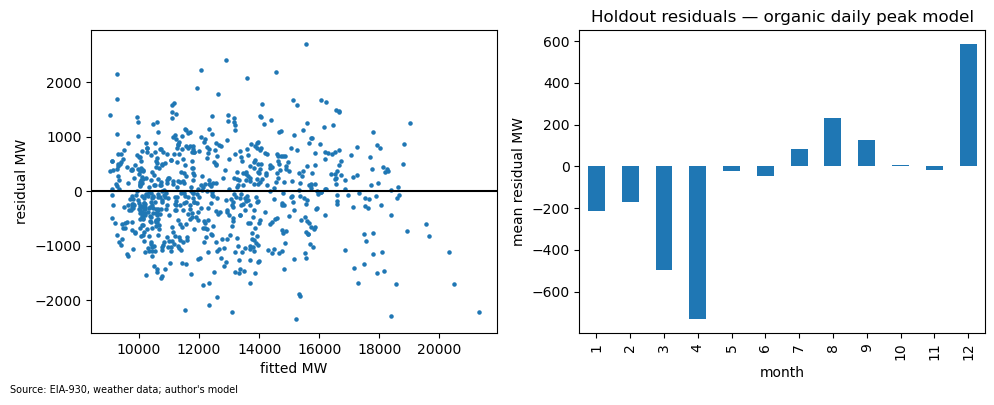

forecast model trend: peak -0.08%/yr, energy -0.26%/yr
normal weather = average of 7 weather years 2019–2025; peak-day adjustment -371 MW
anchoring: peak scale 1.000, energy scale 1.000 (document if far from 1.0)
existing data centers held flat at 5,866 MW connected (as of 2025)
 year  organic_peak_mw  organic_peak_p90_mw  organic_energy_gwh  existing_dc_mw  baseline_peak_mw  baseline_energy_gwh
 2025          19591.0              21119.0             91381.0          5866.0           24283.0             132490.0
 2026          19579.0              21087.0             91133.0          5866.0           24272.0             132242.0
 2027          19445.0              20656.0             90866.0          5866.0           24138.0             131975.0
 2028          19247.0              20180.0             90866.0          5866.0           23939.0             131974.0
 2029          19252.0              21059.0             90406.0          5866.0           23944.0             131515.0
 2030 

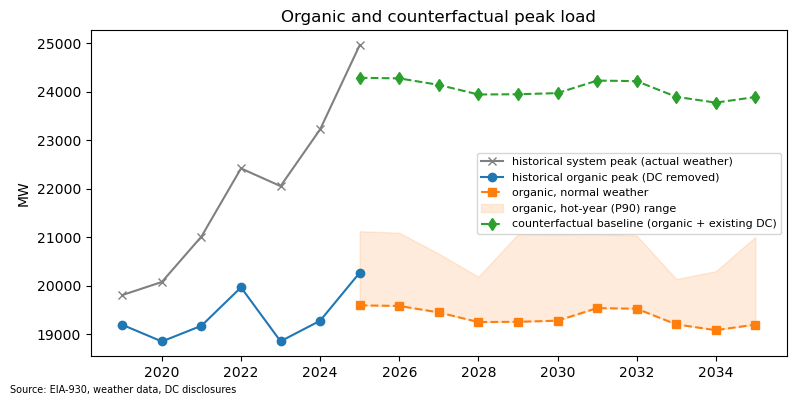

In [10]:
## 4. Baseline forecast (weather-normalized, existing data centers held flat)
def _feats(df, B, hol_dates):
    df = df.copy()
    df["cdd"] = (df.tmean - B).clip(lower=0)
    df["hdd"] = (B - df.tmean).clip(lower=0)
    df["dow"] = df.date.dt.dayofweek
    df["hol"] = df.date.dt.date.isin(hol_dates).astype(int)
    df["t"] = (df.date - pd.Timestamp("2018-01-01")).dt.days / 365.25
    return df


def step_baseline(c):
    import holidays
    import statsmodels.formula.api as smf
    Y = years(c); B = c["degree_day_base_f"]; LF = c["dc_load_factor"]
    load = pd.read_parquet(P["raw"] / "load_hourly.parquet"); wx = pd.read_parquet(P["raw"] / "weather_hourly.parquet")
    d = pd.DataFrame({"peak_mw": load.load_mw.resample("D").max(), "energy_mwh": load.load_mw.resample("D").sum(),
                      "hours": load.load_mw.resample("D").count(), "tmean": wx.temp_f.resample("D").mean()}).dropna()
    d = d[d.hours >= 22].drop(columns="hours").reset_index().rename(columns={"period": "date"})
    d["year"] = d.date.dt.year
    if d.year.nunique() < 4:
        raise SystemExit("need at least 4 years of daily data for the train/holdout split")

    dc_series = load_dc_series(list(d.year.unique()) + Y + [c["base_year"]])
    d["dc_connected_mw"] = d.year.map(dc_series)
    d["organic_peak"] = d.peak_mw - d.dc_connected_mw * LF
    d["organic_energy"] = d.energy_mwh - d.dc_connected_mw * LF * 24
    if (d.organic_peak <= 0).any():
        raise SystemExit("organic_peak <= 0: DC series too large vs load — check units (MW, cumulative)")

    hol_dates = list(holidays.US(years=range(2015, 2041)).keys())
    d = _feats(d, B, hol_dates)
    d.to_parquet(P["interim"] / "daily.parquet")

    train, test = d[d.year <= c["train_end_year"]], d[d.year >= c["test_start_year"]]
    if len(train) < 365 or len(test) < 180:
        raise SystemExit(f"train={len(train)} test={len(test)} days — adjust train_end_year/test_start_year")
    FORM = "{y} ~ cdd + I(cdd**2) + hdd + I(hdd**2) + C(dow) + hol + t"
    m_peak = smf.ols(FORM.format(y="organic_peak"), train).fit()
    m_en = smf.ols(FORM.format(y="organic_energy"), train).fit()

    hist_idx = d.set_index("date")
    rows = []
    for name, m, col in [("peak", m_peak, "organic_peak"), ("energy", m_en, "organic_energy")]:
        naive = test.date.map(lambda x: hist_idx[col].get(x - pd.DateOffset(years=1), np.nan))
        trend_only = smf.ols(f"{col} ~ t", train).fit()
        rows.append({"target": name, "model_mape": mape(test[col], m.predict(test)),
                     "seasonal_naive_mape": mape(test[col], naive), "trend_only_mape": mape(test[col], trend_only.predict(test)),
                     "r2_train": m.rsquared, "trend_coef_per_yr": m.params["t"],
                     "trend_pct_per_yr": m.params["t"] / train[col].mean() * 100})
    val = pd.DataFrame(rows); val.to_csv(P["tab"] / "baseline_validation.csv", index=False)
    display(val.round(3))
    g = val.loc[val.target == "peak", "trend_pct_per_yr"].iloc[0]
    if not (0 <= g <= 2.5):
        print(f"WARNING: organic peak trend {g:.2f}%/yr is outside 0–2.5% — check the de-contamination series")

    # Peak-day bias: the max of fitted daily values sits below the actual annual max, because the actual peak day
    # also has a large positive residual. Measure that gap on TRAINING years and add it to annual peak predictions.
    def _annual_gap(df, model):
        g = df.assign(pred=model.predict(df)).groupby("year").agg(actual=("organic_peak", "max"), pred=("pred", "max"))
        return (g.actual - g.pred)
    peak_adj_train = float(_annual_gap(train, m_peak).mean())
    tp = test.assign(pred=m_peak.predict(test)).groupby("year").agg(actual=("organic_peak", "max"), pred=("pred", "max"))
    tp["pred_adj"] = tp.pred + peak_adj_train
    tp["ape_%"] = (tp.pred_adj - tp.actual).abs() / tp.actual * 100
    print(f"annual-peak adjustment (from training years): {peak_adj_train:+,.0f} MW")
    tp.to_csv(P["tab"] / "baseline_annual_peak_holdout.csv"); print(tp.round(1))

    res = test.organic_peak - m_peak.predict(test)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].scatter(m_peak.predict(test), res, s=5); ax[0].axhline(0, c="k")
    ax[0].set_xlabel("fitted MW"); ax[0].set_ylabel("residual MW")
    res.groupby(test.date.dt.month).mean().plot.bar(ax=ax[1]); ax[1].set_xlabel("month"); ax[1].set_ylabel("mean residual MW")
    savefig("baseline_residuals.png", "Holdout residuals — organic daily peak model", "EIA-930, weather data; author's model")
    rm = res.groupby(test.date.dt.month).agg(["mean", "std", "count"])
    rm.columns = ["mean_mw", "sd_mw", "days"]; rm["t_stat"] = rm.mean_mw / (rm.sd_mw / np.sqrt(rm.days))
    rm["mean_pct_of_peak"] = rm.mean_mw / test.organic_peak.mean() * 100
    rm.rename_axis("month").to_csv(P["tab"] / "baseline_residuals_by_month.csv")

    # validation is done; refit on ALL years (2019-2025) for the actual forecast
    m_peak_fc = smf.ols(FORM.format(y="organic_peak"), d).fit()
    m_en_fc = smf.ols(FORM.format(y="organic_energy"), d).fit()
    print(f"forecast model trend: peak {m_peak_fc.params['t'] / d.organic_peak.mean() * 100:+.2f}%/yr, "
          f"energy {m_en_fc.params['t'] / d.organic_energy.mean() * 100:+.2f}%/yr")

    # normal-weather projection: run every projection year through EACH historical weather year, then average.
    # (Averaging temperatures first would flatten the heat waves that set the annual peak.)
    peak_adj = float(_annual_gap(d, m_peak_fc).mean())   # use all history for the forecast itself
    d["doy"] = d.date.dt.dayofyear
    wx_years = [y for y, g in d.groupby("year") if len(g) >= 330]
    proj_dates = pd.DataFrame({"date": pd.date_range(f"{min(Y + [c['base_year']])}-01-01", f"{Y[-1]}-12-31", freq="D")})
    proj_dates["doy"] = proj_dates.date.dt.dayofyear.clip(upper=365)
    sims = []
    for wy in wx_years:
        temps = (d[d.year == wy].set_index("doy").tmean.reindex(range(1, 366))
                 .interpolate(limit_direction="both"))
        pj = proj_dates.assign(tmean=proj_dates.doy.map(temps))
        pj = _feats(pj, B, hol_dates); pj["year"] = pj.date.dt.year
        pj["peak_pred"] = m_peak_fc.predict(pj); pj["energy_pred"] = m_en_fc.predict(pj)
        sims.append(pj.groupby("year").agg(peak=("peak_pred", "max"), energy=("energy_pred", lambda s: s.sum() / 1000))
                    .assign(weather_year=wy))
    sims = pd.concat(sims).reset_index()
    sims["peak"] += peak_adj
    annual = sims.groupby("year").agg(organic_peak_mw=("peak", "mean"), organic_peak_p90_mw=("peak", lambda s: s.quantile(0.9)),
                                      organic_energy_gwh=("energy", "mean")).reset_index()
    print(f"normal weather = average of {len(wx_years)} weather years {wx_years[0]}–{wx_years[-1]}; "
          f"peak-day adjustment {peak_adj:+,.0f} MW")

    scale_p = scale_e = 1.0
    if (c["anchor_to_base_year"] and not c["synthetic_mode"] and c["base_year"] in annual.year.values
            and c.get("peak_base_2024_mw") and c.get("energy_base_2024_gwh")):
        target_p = c["peak_base_2024_mw"] - dc_series[c["base_year"]] * LF
        target_e = c["energy_base_2024_gwh"] - dc_series[c["base_year"]] * LF * 8.76
        scale_p = target_p / annual.loc[annual.year == c["base_year"], "organic_peak_mw"].iloc[0]
        scale_e = target_e / annual.loc[annual.year == c["base_year"], "organic_energy_gwh"].iloc[0]
    print(f"anchoring: peak scale {scale_p:.3f}, energy scale {scale_e:.3f} (document if far from 1.0)")
    annual["organic_peak_mw"] *= scale_p; annual["organic_peak_p90_mw"] *= scale_p; annual["organic_energy_gwh"] *= scale_e

    # existing DC = everything connected as of the LAST year in the DC history file. Projects already energized are
    # excluded from the pipeline overlay, so they must be in the counterfactual baseline — otherwise they'd vanish.
    dc_obs = pd.read_csv(P["raw"] / "dc_historical_connected_mw.csv").dropna(subset=["dc_connected_mw"])
    last_obs = int(min(dc_obs.year.max(), c["horizon_end"]))
    dc_exist = float(dc_series[last_obs])
    print(f"existing data centers held flat at {dc_exist:,.0f} MW connected (as of {last_obs})")
    annual["existing_dc_mw"] = dc_exist
    annual["baseline_peak_mw"] = annual.organic_peak_mw + dc_exist * LF
    annual["baseline_energy_gwh"] = annual.organic_energy_gwh + dc_exist * LF * 8.76
    annual = annual[annual.year.isin(Y)]
    annual.to_csv(P["tab"] / "baseline_annual.csv", index=False)

    hist = d.groupby("year").agg(organic_peak_mw=("organic_peak", "max"), system_peak_mw=("peak_mw", "max"),
                                 organic_energy_gwh=("organic_energy", lambda s: s.sum() / 1000)).reset_index()
    hist.to_csv(P["tab"] / "baseline_history.csv", index=False)
    print(annual.round(0).to_string(index=False))

    plt.figure(figsize=(8, 4))
    plt.plot(hist.year, hist.system_peak_mw, "x-", c="grey", label="historical system peak (actual weather)")
    plt.plot(hist.year, hist.organic_peak_mw, "o-", label="historical organic peak (DC removed)")
    plt.plot(annual.year, annual.organic_peak_mw, "s--", label="organic, normal weather")
    plt.fill_between(annual.year, annual.organic_peak_mw, annual.organic_peak_p90_mw, alpha=0.15, color="C1",
                     label="organic, hot-year (P90) range")
    plt.plot(annual.year, annual.baseline_peak_mw, "d--", label="counterfactual baseline (organic + existing DC)")
    plt.ylabel("MW"); plt.legend(fontsize=8)
    savefig("baseline_peak.png", "Organic and counterfactual peak load", "EIA-930, weather data, DC disclosures")


step_baseline(c)

## 5. Data-center pipeline: de-duplicate, funnel, Low/Base/High scenarios

rows: 46 → explicit dups removed: 0 → heuristic dups removed: 0 [] → kept: 46
                         projects      mw
stage                                    
announced                     6.0  3081.0
zoned                         3.0  2450.0
interconnection_request       0.0     0.0
esa_signed                   30.0  9291.0
construction                  7.0  2708.4
energized                     0.0     0.0


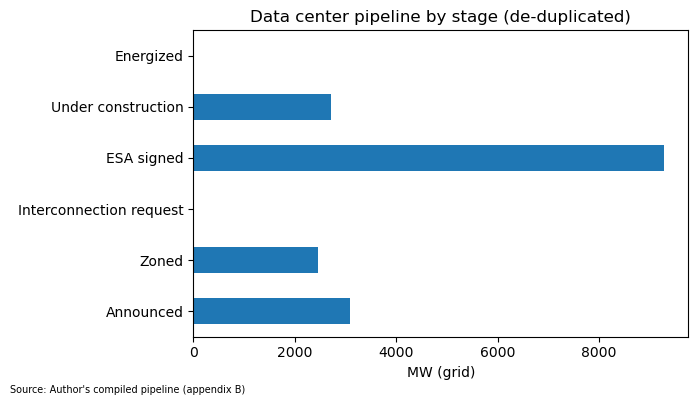

scenario     base     high     low
year                              
2025        158.0    409.0     8.0
2026        483.0    993.0   169.0
2027       1216.0   2007.0   707.0
2028       2768.0   3951.0  1922.0
2029       4874.0   6640.0  3506.0
2030       7068.0   9456.0  5118.0
2031       9013.0  12012.0  6499.0
2032      10919.0  14509.0  7857.0
2033      12150.0  16148.0  8719.0
2034      12886.0  17229.0  9178.0
2035      13126.0  17753.0  9234.0


In [11]:
def step_pipeline(c):
    Y = years(c); ORDER = {s: i for i, s in enumerate(STAGES)}
    pipe = pd.read_csv(P["proc"] / "pipeline.csv")
    pipe = pipe[~pipe.campus_name.astype(str).str.contains("EXAMPLE", case=False, na=False)].copy()
    if pipe.empty:
        raise SystemExit("pipeline.csv has no real rows — fill it in first")
    pipe["stage_raw"] = pipe.stage
    pipe["stage"] = pipe.stage.map(normalize_stage)
    bad = pipe[pipe.stage.isna()]
    if len(bad):
        raise SystemExit(f"Unrecognized stage values {bad.stage_raw.unique().tolist()} in rows {bad.project_id.tolist()}. Allowed: {STAGES}")
    pipe["capacity_mw_grid"] = pd.to_numeric(pipe.capacity_mw_grid, errors="coerce")
    pipe["capacity_mw_it"] = pd.to_numeric(pipe.capacity_mw_it, errors="coerce")
    pipe["capacity_mw_grid"] = pipe.capacity_mw_grid.fillna(pipe.capacity_mw_it * c["dc_pue_default"])
    pipe = pipe.dropna(subset=["capacity_mw_grid"])
    ann_year = pd.to_datetime(pipe.announced_date, errors="coerce").dt.year
    pipe["expected_cod"] = (pd.to_numeric(pipe.expected_cod, errors="coerce")
                            .fillna(ann_year + 3).fillna(c["base_year"] + 3).astype(int))
    pipe["developer"] = pipe.developer.fillna("UNKNOWN"); pipe["county"] = pipe.county.fillna("UNKNOWN")

    n_in = len(pipe)
    dup_col = pipe.duplicate_of if "duplicate_of" in pipe else pd.Series(np.nan, index=pipe.index)
    explicit = dup_col.notna() & (dup_col.astype(str).str.strip() != "")
    pipe = pipe[~explicit].copy()
    pipe["stage_rank"] = pipe.stage.map(ORDER)
    keep, dropped = [], []
    for (county, dev), g in pipe.groupby(["county", "developer"]):
        g = g.sort_values(["stage_rank", "capacity_mw_grid"], ascending=False)
        if dev == "UNKNOWN":          # can't infer duplicates without a developer
            keep += g.project_id.tolist(); continue
        kept = []
        for _, r in g.iterrows():
            if any(abs(r.capacity_mw_grid - k.capacity_mw_grid) / k.capacity_mw_grid < 0.20
                   and abs(r.expected_cod - k.expected_cod) <= 2 for k in kept):
                dropped.append(r.project_id); continue
            kept.append(r); keep.append(r.project_id)
    dedup = pipe[pipe.project_id.isin(keep)].copy()
    print(f"rows: {n_in} → explicit dups removed: {int(explicit.sum())} → heuristic dups removed: {len(dropped)} {dropped} → kept: {len(dedup)}")
    dedup.drop(columns=["stage_raw", "stage_rank"]).to_csv(P["proc"] / "pipeline_dedup.csv", index=False)

    funnel = dedup.groupby("stage").agg(projects=("project_id", "count"), mw=("capacity_mw_grid", "sum")).reindex(STAGES).fillna(0)
    funnel.to_csv(P["tab"] / "pipeline_funnel.csv"); print(funnel)
    funnel.rename(index=LABEL).mw.plot.barh(figsize=(7, 4)); plt.xlabel("MW (grid)"); plt.ylabel("")
    savefig("pipeline_funnel.png", "Data center pipeline by stage (de-duplicated)", "Author's compiled pipeline (appendix B)")

    ov = dedup[dedup.stage != "energized"] if c["exclude_energized_from_overlay"] else dedup
    rows = []
    for scen in ["low", "base", "high"]:
        prob = c["stage_prob"][scen]
        for y in Y:
            mw = sum(prob[r.stage] * r.capacity_mw_grid *
                     ramp_fraction(y, r.expected_cod + c["stage_delay_median_yrs"][r.stage], c["stage_ramp_yrs"][r.stage])
                     for r in ov.itertuples())
            mw += c["unannounced_mw_per_yr"][scen] * max(y - c["base_year"], 0)
            rows.append({"scenario": scen, "year": y, "dc_peak_mw": mw})
    sc = pd.DataFrame(rows); sc["dc_energy_gwh"] = sc.dc_peak_mw * 8.76 * c["dc_load_factor"]
    sc.to_csv(P["tab"] / "dc_scenarios.csv", index=False)
    print(sc.pivot(index="year", columns="scenario", values="dc_peak_mw").round(0))


step_pipeline(c)

## 6. Monte Carlo

          p5      p25      p50      p75      p95
year                                            
2025    11.0     92.0    159.0    226.0    324.0
2026   200.0    352.0    466.0    585.0    743.0
2027   666.0   1006.0   1256.0   1501.0   1841.0
2028  1588.0   2268.0   2742.0   3215.0   3947.0
2029  2853.0   3921.0   4663.0   5379.0   6543.0
2030  4238.0   5654.0   6623.0   7602.0   9161.0
2031  5517.0   7269.0   8491.0   9726.0  11566.0
2032  6720.0   8803.0  10255.0  11681.0  13652.0
2033  7692.0  10020.0  11655.0  13137.0  15139.0
2034  8323.0  10833.0  12507.0  14063.0  16073.0
2035  8661.0  11259.0  12957.0  14543.0  16569.0
independent-projects range (for comparison):
           p5      p50      p95
year                           
2025     11.0    155.0    318.0
2026    217.0    472.0    737.0
2027    830.0   1275.0   1639.0
2028   2106.0   2835.0   3407.0
2029   3790.0   4815.0   5707.0
2030   5587.0   6843.0   8119.0
2031   7220.0   8728.0  10371.0
2032   8797.0  10510.0  12323.

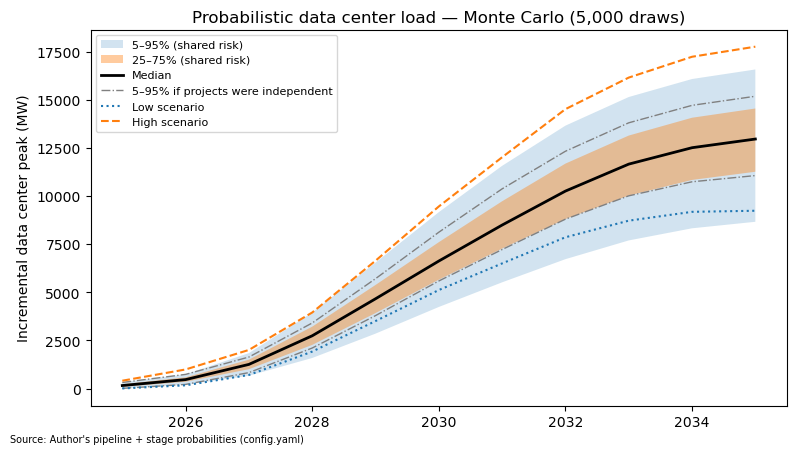

In [12]:
def step_mc(c):
    Y = years(c); rng = np.random.default_rng(c["seed"]); LF = c["dc_load_factor"]
    pipe = pd.read_csv(P["proc"] / "pipeline_dedup.csv")
    if c["exclude_energized_from_overlay"]:
        pipe = pipe[pipe.stage != "energized"]
    base = pd.read_csv(P["tab"] / "baseline_annual.csv").set_index("year").reindex(Y)
    if base.baseline_peak_mw.isna().any():
        raise SystemExit("baseline_annual.csv does not cover the full horizon — rerun baseline")
    cap = pipe.capacity_mw_grid.values.astype(float)
    p = pipe.stage.map(c["stage_prob"]["base"]).values.astype(float)
    dmed = pipe.stage.map(c["stage_delay_median_yrs"]).values.astype(float)
    ramp = pipe.stage.map(c["stage_ramp_yrs"]).values.astype(float)
    cod0 = pipe.expected_cod.values.astype(float); yrs = np.array(Y, float); N = c["mc_draws"]
    logit_p = np.log(np.clip(p, 1e-6, 1 - 1e-6) / np.clip(1 - p, 1e-6, 1))

    def simulate(correlated, rng):
        out = np.zeros((N, len(Y)))
        for i in range(N):
            if correlated:   # one shared shock per draw moves every project's odds and timing together
                z = rng.normal(0, c["mc_common_logit_sd"]); dmult = np.exp(rng.normal(0, c["mc_common_delay_sd"]))
                pi = 1 / (1 + np.exp(-(logit_p + z)))
            else:
                pi, dmult = p, 1.0
            built = rng.random(len(cap)) < pi
            cod = cod0 + dmult * rng.lognormal(np.log(np.maximum(dmed, 0.1)), c["stage_delay_sigma"])
            frac = np.clip((yrs[None, :] + 1 - cod[:, None]) / np.maximum(ramp[:, None], 1e-6), 0, 1)
            out[i] = (cap * built) @ frac
            out[i] += np.cumsum(rng.normal(c["unannounced_mw_per_yr"]["base"], c["unannounced_sd"], len(Y)).clip(min=0)) * (yrs > c["base_year"])
        return out

    def pctl(out):
        return pd.DataFrame(np.percentile(out, [5, 25, 50, 75, 95], axis=0).T, index=pd.Index(Y, name="year"),
                            columns=["p5", "p25", "p50", "p75", "p95"])

    out_ind = simulate(False, np.random.default_rng(c["seed"]))
    pct_ind = pctl(out_ind); pct_ind.to_csv(P["tab"] / "dc_fan_independent.csv")
    if c.get("mc_correlated", True):
        out = simulate(True, np.random.default_rng(c["seed"] + 1))
    else:
        out = out_ind
    np.save(P["proc"] / "mc_draws.npy", out)
    pct = pctl(out)
    pct.to_csv(P["tab"] / "dc_fan.csv"); print(pct.round(0))
    print("independent-projects range (for comparison):"); print(pct_ind[["p5", "p50", "p95"]].round(0))

    sc = pd.read_csv(P["tab"] / "dc_scenarios.csv")

    def frame(name, dc_peak):
        dc_peak = np.asarray(dc_peak, float)
        return pd.DataFrame({"scenario": name, "year": Y, "baseline_peak_mw": base.baseline_peak_mw.values,
                             "dc_peak_mw": dc_peak, "total_peak_mw": base.baseline_peak_mw.values + dc_peak,
                             "baseline_energy_gwh": base.baseline_energy_gwh.values, "dc_energy_gwh": dc_peak * 8.76 * LF})
    frames = [frame(s, sc[sc.scenario == s].set_index("year").reindex(Y).dc_peak_mw.values) for s in ["low", "base", "high"]]
    frames += [frame(f"mc_{q}", pct[q].values) for q in ["p5", "p50", "p95"]]
    tot = pd.concat(frames); tot["total_energy_gwh"] = tot.baseline_energy_gwh + tot.dc_energy_gwh
    tot.to_csv(P["tab"] / "total_load_scenarios.csv", index=False)

    plt.figure(figsize=(8, 4.5))
    plt.fill_between(Y, pct.p5, pct.p95, alpha=0.2, label="5–95% (shared risk)")
    plt.fill_between(Y, pct.p25, pct.p75, alpha=0.4, label="25–75% (shared risk)")
    plt.plot(Y, pct.p50, "k-", lw=2, label="Median")
    if c.get("mc_correlated", True):
        plt.plot(Y, pct_ind.p5, color="grey", lw=1, ls="-.", label="5–95% if projects were independent")
        plt.plot(Y, pct_ind.p95, color="grey", lw=1, ls="-.")
    for s, ls in [("low", ":"), ("high", "--")]:
        plt.plot(Y, sc[sc.scenario == s].set_index("year").reindex(Y).dc_peak_mw.values, ls, label=f"{s.capitalize()} scenario")
    plt.ylabel("Incremental data center peak (MW)"); plt.legend(fontsize=8)
    savefig("dc_fan_chart.png", f"Probabilistic data center load — Monte Carlo ({N:,} draws)",
            "Author's pipeline + stage probabilities (config.yaml)")


step_mc(c)

## 7. Capital → rate base → revenue requirement → rates → earnings

,variant,year,dc_peak_mw,total_peak_mw,cum_capex_bn,rate_base_bn,rate_cf_c_kwh,rate_sc_c_kwh,rate_delta_c_kwh,rate_delta_pct,d_net_income_mn
5,low,2030,5117.64,29085.35,31.25,27.54,12.32,13.30,0.98,7.99,1404.17
10,low,2035,9233.77,33121.02,58.57,45.32,13.93,15.06,1.12,8.06,2310.94
16,base,2030,7067.65,31035.36,43.05,37.79,12.32,13.56,1.24,10.09,1927.16
21,base,2035,13125.73,37012.98,83.37,64.65,13.93,15.35,1.41,10.13,3297.03
27,high,2030,9456.50,33424.21,57.41,50.17,12.32,13.82,1.50,12.18,2558.42
32,high,2035,17753.02,41640.28,112.76,87.49,13.93,15.60,1.67,11.96,4461.30
38,mc_p5,2030,4237.85,28205.56,25.87,22.78,12.32,13.16,0.84,6.86,1161.44
43,mc_p5,2035,8660.77,32548.03,55.45,43.58,13.93,15.07,1.14,8.15,2222.10
49,mc_p50,2030,6622.91,30590.62,40.28,35.29,12.32,13.49,1.18,9.56,1799.66
54,mc_p50,2035,12957.04,36844.30,82.61,64.49,13.93,15.37,1.43,10.28,3288.59


saved model/capital_rate_model.xlsx


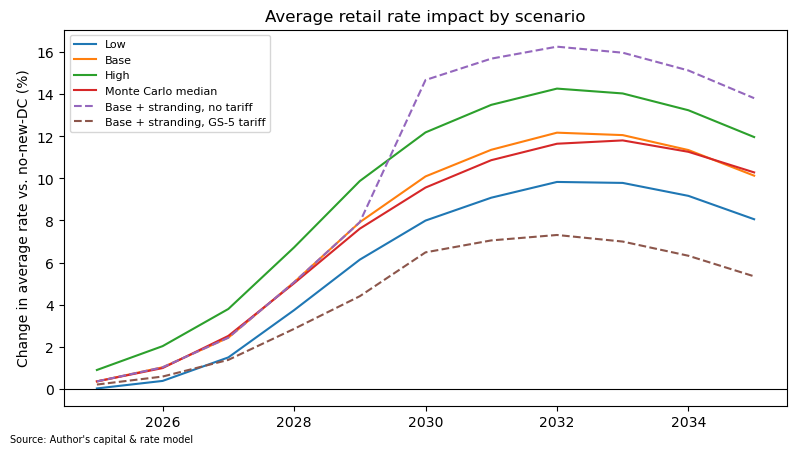

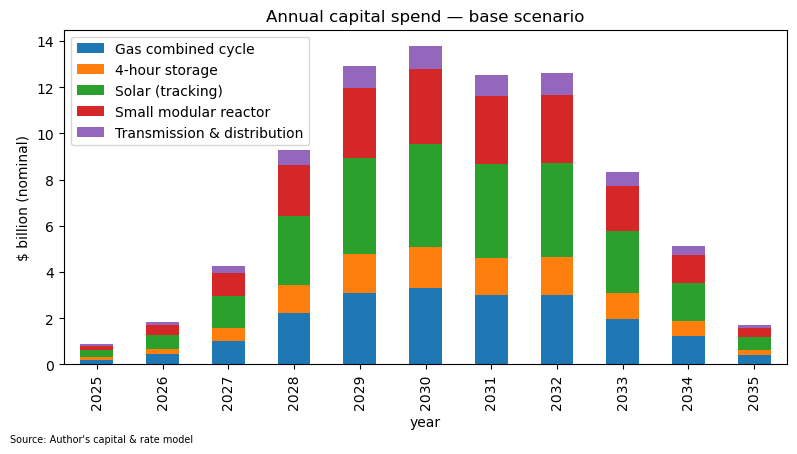

In [13]:
def run_model(dc_peak_mw, baseline_peak_mw, baseline_energy_gwh, c, tariff=False, stranded_share=0.0, overrides=None):
    """All three inputs are pd.Series indexed by year. dc_peak_mw = incremental vs counterfactual baseline."""
    c = {**c, **(overrides or {})}
    Y = list(dc_peak_mw.index); b = c["base_year"]; LF = c["dc_load_factor"]; infl = c["inflation"]
    ptw = c["equity_share"] * c["roe"] / (1 - c["tax_rate"]) + (1 - c["equity_share"]) * c["cost_of_debt"]  # pre-tax WACC
    ciac = c["tariff_ciac_share"] if tariff else c["ciac_share"]; capex_mult = c.get("capex_mult", 1.0)
    gross = {k: 0.0 for k in TECHS + ["td"]}; nameplate = {k: 0.0 for k in TECHS}
    rb = {"gen": 0.0, "td": 0.0}; prev_dc = 0.0; rows = []
    for y in Y:
        n = y - b; inf = (1 + infl) ** n; dc = float(dc_peak_mw[y])
        build_for = max(dc, prev_dc)                      # capacity is never un-built
        stranded = (stranded_share * float(dc_peak_mw.get(c["stranded_year"], dc))
                    if (stranded_share and y >= c["stranded_year"]) else 0.0)
        served = max(dc - stranded, 0.0)
        add_peak = build_for - prev_dc; prev_dc = build_for
        accredited = add_peak * c["fpr"]                  # PJM forecast pool requirement, in accredited MW
        capex = {k: (accredited * c["resource_shares"][k] / c["elcc"][k]) * 1000 * c["capex_per_kw"][k] * inf * capex_mult for k in TECHS}
        for k in TECHS:
            nameplate[k] += accredited * c["resource_shares"][k] / c["elcc"][k]
        capex["td"] = add_peak * 1000 * c["td_capex_per_kw_peak"] * inf * capex_mult
        capex_total = sum(capex.values())
        for k in capex:
            gross[k] += capex[k] * (1 - ciac)
        dep_gen = sum(gross[k] / c["book_life_yrs"][k] for k in TECHS)
        dep_td = gross["td"] / c["book_life_yrs"]["td"]
        rb["gen"] = max(rb["gen"] + sum(capex[k] for k in TECHS) * (1 - ciac) - dep_gen, 0.0)
        rb["td"] = max(rb["td"] + capex["td"] * (1 - ciac) - dep_td, 0.0)
        dep = dep_gen + dep_td; rate_base = rb["gen"] + rb["td"]
        fom = sum(nameplate[k] * 1000 * c["fom_per_kw_yr"][k] * inf for k in TECHS)
        dc_mwh = served * 8760 * LF; fuel = dc_mwh * c["marginal_energy_cost_per_mwh"] * inf
        fixed_gen = rb["gen"] * ptw + dep_gen + fom      # fixed generation cost recovered in rates
        fixed_td = rb["td"] * ptw + dep_td               # fixed T&D cost recovered in rates
        d_rr = fixed_gen + fixed_td + fuel
        # GS-5 style minimum bill: the customers whose load did not arrive still pay 60% of the fixed generation
        # cost and 85% of the fixed T&D cost built for that load
        f_str = stranded / build_for if build_for > 0 else 0.0
        min_bill = f_str * (c["gs5_min_gen"] * fixed_gen + c["gs5_min_td"] * fixed_td) if tariff else 0.0
        e_cf = float(baseline_energy_gwh[y]) * 1000                       # MWh
        rate_cf = c["retail_rate_2024_c_kwh"] * inf                         # ¢/kWh, counterfactual
        rr_cf = rate_cf * e_cf * 10                                         # $ (¢/kWh × MWh × 10)
        rate_sc = (rr_cf + d_rr - min_bill) / (e_cf + dc_mwh) * 0.1         # ¢/kWh
        rows.append(dict(year=y, baseline_peak_mw=float(baseline_peak_mw[y]), dc_peak_mw=dc, stranded_mw=stranded,
                         total_peak_mw=float(baseline_peak_mw[y]) + served, accredited_add_mw=accredited,
                         capex_total_usd=capex_total, **{f"capex_{k}_usd": v for k, v in capex.items()},
                         rate_base_usd=rate_base, rate_base_gen_usd=rb["gen"], rate_base_td_usd=rb["td"],
                         depreciation_usd=dep, fom_usd=fom, fuel_usd=fuel, d_rr_usd=d_rr,
                         min_bill_usd=min_bill, rr_cf_usd=rr_cf, rate_cf_c_kwh=rate_cf, rate_sc_c_kwh=rate_sc,
                         rate_delta_c_kwh=rate_sc - rate_cf, rate_delta_pct=(rate_sc / rate_cf - 1) * 100,
                         d_net_income_usd=rate_base * c["equity_share"] * c["roe"]))
    return pd.DataFrame(rows)


def _scenario_inputs(c):
    Y = years(c)
    tot = pd.read_csv(P["tab"] / "total_load_scenarios.csv")
    base = pd.read_csv(P["tab"] / "baseline_annual.csv").set_index("year").reindex(Y)
    dc = {s: g.set_index("year").reindex(Y).dc_peak_mw for s, g in tot.groupby("scenario")}
    return base, dc


def all_variants(c, base, dc, overrides=None):
    variants = {s: dict(dc=dc[s], tariff=False, stranded=0.0) for s in ["low", "base", "high", "mc_p5", "mc_p50", "mc_p95"] if s in dc}
    variants["base_stranded"] = dict(dc=dc["base"], tariff=False, stranded=c["stranded_share"])
    variants["base_stranded_tariff"] = dict(dc=dc["base"], tariff=True, stranded=c["stranded_share"])
    out = []
    for name, v in variants.items():
        r = run_model(v["dc"], base.baseline_peak_mw, base.baseline_energy_gwh, c, tariff=v["tariff"],
                      stranded_share=v["stranded"], overrides=overrides)
        r.insert(0, "variant", name); out.append(r)
    res = pd.concat(out, ignore_index=True)
    res["cum_capex_usd"] = res.groupby("variant").capex_total_usd.cumsum()
    return res


def step_model(c):
    base, dc = _scenario_inputs(c)
    res = all_variants(c, base, dc)
    res.to_csv(P["tab"] / "model_results.csv", index=False)
    ry = [y for y in c["report_years"] if y in res.year.values] or [res.year.max()]
    head = res[res.year.isin(ry)].assign(
        cum_capex_bn=lambda d: d.cum_capex_usd / 1e9, rate_base_bn=lambda d: d.rate_base_usd / 1e9,
        d_net_income_mn=lambda d: d.d_net_income_usd / 1e6)[
        ["variant", "year", "dc_peak_mw", "total_peak_mw", "cum_capex_bn", "rate_base_bn",
         "rate_cf_c_kwh", "rate_sc_c_kwh", "rate_delta_c_kwh", "rate_delta_pct", "d_net_income_mn"]]
    head.to_csv(P["tab"] / "headline_table.csv", index=False)
    display(head.round(2))

    xl = P["model"] / "capital_rate_model.xlsx"
    try:
        flat = pd.json_normalize({k: v for k, v in c.items() if k != "eia_api_key"}, sep=".").T.reset_index()
        flat.columns = ["assumption", "value"]; flat["value"] = flat.value.astype(str)
        with pd.ExcelWriter(xl) as w:
            if c["synthetic_mode"]:
                pd.DataFrame({"WARNING": ["SYNTHETIC DATA — NOT FOR REPORTING"]}).to_excel(w, sheet_name="README", index=False)
            flat.to_excel(w, sheet_name="Assumptions", index=False)
            pd.read_csv(P["tab"] / "total_load_scenarios.csv").to_excel(w, sheet_name="Load_Scenarios", index=False)
            head.to_excel(w, sheet_name="Headline", index=False)
            for v, g in res.groupby("variant", sort=False):
                g.to_excel(w, sheet_name=v[:31], index=False)
        print(f"saved {xl.relative_to(ROOT)}")
    except Exception as e:
        print(f"(Excel export skipped: {e})")

    plt.figure(figsize=(8, 4.5))
    for v, g in res.groupby("variant", sort=False):
        if v in ("mc_p5", "mc_p95"):
            continue
        plt.plot(g.year, g.rate_delta_pct, label=LABEL.get(v, v), ls="--" if "stranded" in v else "-")
    plt.axhline(0, c="k", lw=0.8); plt.ylabel("Change in average rate vs. no-new-DC (%)"); plt.legend(fontsize=8)
    savefig("rate_impact.png", "Average retail rate impact by scenario", "Author's capital & rate model")

    b = res[res.variant == "base"].set_index("year")
    cols = [f"capex_{k}_usd" for k in TECHS + ["td"]]
    (b[cols] / 1e9).rename(columns=lambda s: LABEL[s.replace("capex_", "").replace("_usd", "")]).plot.bar(stacked=True, figsize=(8, 4.5))
    plt.ylabel("$ billion (nominal)")
    savefig("capex_by_tech.png", "Annual capital spend — base scenario", "Author's capital & rate model")


step_model(c)

## 8. Sensitivity (tornado)

rate impact 2035, base = 10.13%


,driver,base_value,low_input,high_input,swing
0,T&D cost per kW ±50%,10.13,9.15,11.10,1.95
1,ROE ±100bp,10.13,8.66,11.59,2.93
2,Inflation 1.5% / 4%,10.13,11.37,8.40,2.97
3,Reserve requirement ±0.05,10.13,8.52,11.74,3.22
4,Data center build-out: Low / High scenario,10.13,8.06,11.96,3.91
5,Upfront customer share (CIAC) 0% / 25%,10.13,11.59,4.28,7.31
6,Capital cost ±20%,10.13,4.57,15.69,11.11
7,Energy cost ±30%,10.13,4.19,16.06,11.87
8,DC load factor 0.50 / 0.90,10.13,21.60,7.06,14.54


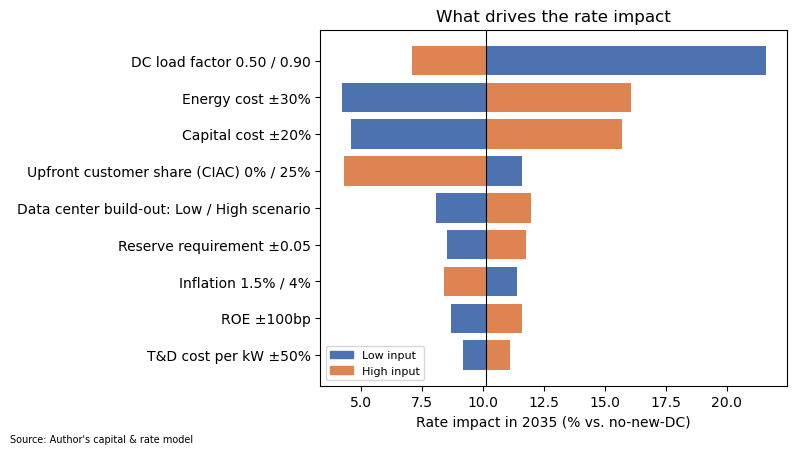

In [14]:
def step_sens(c):
    base, dc = _scenario_inputs(c)
    yr = c["horizon_end"]

    def metric(overrides=None, scen="base"):
        r = run_model(dc[scen], base.baseline_peak_mw, base.baseline_energy_gwh, c, overrides=overrides)
        return float(r.set_index("year").loc[yr, "rate_delta_pct"])

    center = metric()
    tests = [
        ("Capital cost ±20%", {"capex_mult": 0.8}, {"capex_mult": 1.2}),
        ("ROE ±100bp", {"roe": c["roe"] - 0.01}, {"roe": c["roe"] + 0.01}),
        ("Reserve requirement ±0.05", {"fpr": c["fpr"] - 0.05}, {"fpr": c["fpr"] + 0.05}),
        ("DC load factor 0.50 / 0.90", {"dc_load_factor": 0.50}, {"dc_load_factor": 0.90}),
        ("Upfront customer share (CIAC) 0% / 25%", {"ciac_share": 0.0}, {"ciac_share": 0.25}),
        ("Energy cost ±30%", {"marginal_energy_cost_per_mwh": c["marginal_energy_cost_per_mwh"] * 0.7},
         {"marginal_energy_cost_per_mwh": c["marginal_energy_cost_per_mwh"] * 1.3}),
        ("T&D cost per kW ±50%", {"td_capex_per_kw_peak": c["td_capex_per_kw_peak"] * 0.5},
         {"td_capex_per_kw_peak": c["td_capex_per_kw_peak"] * 1.5}),
        ("Inflation 1.5% / 4%", {"inflation": 0.015}, {"inflation": 0.04}),
    ]
    rows = [{"driver": n, "low_input": metric(lo), "high_input": metric(hi)} for n, lo, hi in tests]
    rows.append({"driver": "Data center build-out: Low / High scenario", "low_input": metric(scen="low"), "high_input": metric(scen="high")})
    t = pd.DataFrame(rows)
    t["swing"] = (t.high_input - t.low_input).abs()
    t = t.sort_values("swing").reset_index(drop=True)
    t.insert(1, "base_value", center)
    t.to_csv(P["tab"] / "sensitivity_tornado.csv", index=False)
    print(f"rate impact {yr}, base = {center:.2f}%"); display(t.round(2))

    plt.figure(figsize=(8, 4.5))
    for i, r in t.iterrows():
        lo, hi = r.low_input - center, r.high_input - center
        plt.barh(i, lo, left=center, color="#4c72b0"); plt.barh(i, hi, left=center, color="#dd8452")
    plt.yticks(range(len(t)), t.driver); plt.axvline(center, c="k", lw=0.8)
    plt.xlabel(f"Rate impact in {yr} (% vs. no-new-DC)")
    plt.legend(handles=[plt.Rectangle((0, 0), 1, 1, color="#4c72b0"), plt.Rectangle((0, 0), 1, 1, color="#dd8452")],
               labels=["Low input", "High input"], fontsize=8)
    savefig("sensitivity_tornado.png", "What drives the rate impact", "Author's capital & rate model")


step_sens(c)

## 9. Benchmark against official forecasts

                          source  vintage      metric  year  external  model_base  model_p5  model_p95  diff_pct  within_p5_p95
PJM 2026 Load Forecast (derived)     2026 summer_peak  2030   31095.0     31035.4   28205.6    33128.5      -0.2           True
PJM 2026 Load Forecast (derived)     2026 summer_peak  2035   40448.0     37013.0   32548.0    40456.6      -8.5           True


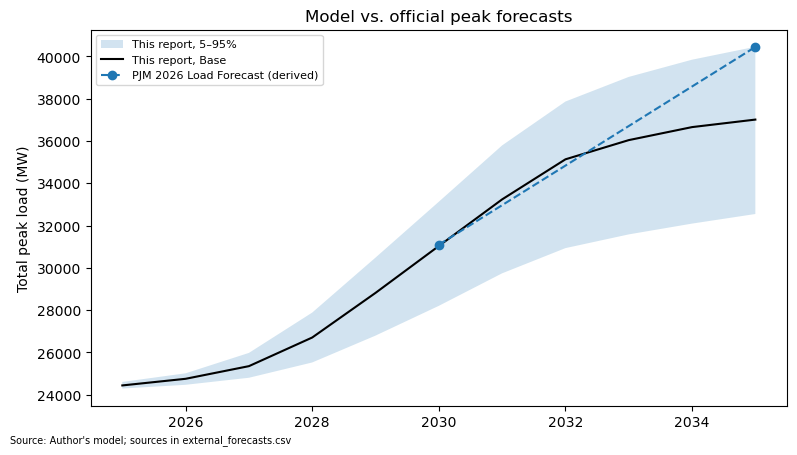

In [15]:
def step_bench(c):
    ext = pd.read_csv(P["raw"] / "external_forecasts.csv")
    ext = ext[pd.to_numeric(ext.get("value_mw"), errors="coerce").notna()] if "value_mw" in ext else ext.iloc[0:0]
    out_path = P["tab"] / "benchmark.csv"
    if ext.empty:
        pd.DataFrame(columns=["source", "vintage", "metric", "year", "external", "model_base", "model_p5", "model_p95",
                              "diff_pct", "within_p5_p95"]).to_csv(out_path, index=False)
        print("no external forecasts yet — wrote empty benchmark.csv"); return
    tot = pd.read_csv(P["tab"] / "total_load_scenarios.csv")
    col = {"summer_peak": "total_peak_mw", "peak": "total_peak_mw", "energy": "total_energy_gwh", "annual_energy": "total_energy_gwh"}
    piv = {m: tot.pivot(index="year", columns="scenario", values=v) for m, v in set(col.items())}
    rows = []
    for r in ext.itertuples():
        m = str(r.metric).strip().lower()
        if m not in col or int(r.year) not in piv[m].index:
            print(f"  skipping {r.source} {r.metric} {r.year} (unknown metric or outside horizon)"); continue
        p = piv[m].loc[int(r.year)]
        rows.append(dict(source=r.source, vintage=r.vintage, metric=m, year=int(r.year), external=float(r.value_mw),
                         model_base=p["base"], model_p5=p.get("mc_p5"), model_p95=p.get("mc_p95"),
                         diff_pct=(p["base"] / float(r.value_mw) - 1) * 100,
                         within_p5_p95=bool(p.get("mc_p5") <= float(r.value_mw) <= p.get("mc_p95"))))
    b = pd.DataFrame(rows); b.to_csv(out_path, index=False); print(b.round(1).to_string(index=False))

    pk = tot.pivot(index="year", columns="scenario", values="total_peak_mw")
    plt.figure(figsize=(8, 4.5))
    plt.fill_between(pk.index, pk.mc_p5, pk.mc_p95, alpha=0.2, label="This report, 5–95%")
    plt.plot(pk.index, pk.base, "k-", label="This report, Base")
    e = b[b.metric.isin(["summer_peak", "peak"])]
    for s, g in e.groupby("source"):
        plt.plot(g.year, g.external, "o--", label=s)
    plt.ylabel("Total peak load (MW)"); plt.legend(fontsize=8)
    savefig("benchmark_peak.png", "Model vs. official peak forecasts", "Author's model; sources in external_forecasts.csv")


step_bench(c)

## 10. Build the Word report
Writes `report/report.docx` (or `report_synthetic/report.docx` in fake-data mode) with every number, chart and table filled in from the steps above. Red **[EDIT: …]** notes in the document mark the places where you need to add your own sources or interpretation.

In [ ]:
WORKS_CITED = [  # MLA 9, alphabetical. *text* = italics.
    'DiGangi, Diana. "Dominion Ordered to Directly Assign Some Transmission Costs to Data Centers." *Utility Dive*, 12 Aug. 2026, www.utilitydive.com/news/dominion-energy-scc-transmission-costs-data-center/827693/. Accessed 4 Oct. 2026.',
    '---. "Dominion Unveils Plans to Add 21 GW of Clean Energy, 5.9 GW of Gas Generation by 2039." *Utility Dive*, 16 Oct. 2024, www.utilitydive.com/news/dominion-integrated-resource-plan-irp-renewables-natural-gas/729989/. Accessed 4 Oct. 2026.',
    '"Dominion Q2 2026 Slides: Data Centers Surge, Offshore Wind 81% Done." *Investing.com*, 31 July 2026, www.investing.com/news/company-news/dominion-q2-2026-slides-data-centers-surge-offshore-wind-81-done-93CH-4828982. Accessed 4 Oct. 2026.',
    'GridLab. *The New Reality of Power Generation: An Analysis of Increasing Gas Turbine Costs*. GridLab, Sept. 2025, gridlab.org/wp-content/uploads/2025/09/GridLab_Gas-Turbine-Costs-Report-1.pdf. Accessed 4 Oct. 2026.',
    'Joint Legislative Audit and Review Commission. *Data Centers in Virginia*. Report no. 598, Commonwealth of Virginia, Dec. 2024, jlarc.virginia.gov/landing-2024-data-centers-in-virginia.asp. Accessed 4 Oct. 2026.',
    'Martucci, Brian. "A Fraction of Proposed Data Centers Will Get Built. Utilities Are Wising Up." *Utility Dive*, 15 May 2025, www.utilitydive.com/news/a-fraction-of-proposed-data-centers-will-get-built-utilities-are-wising-up/748214/. Accessed 4 Oct. 2026.',
    'Monitoring Analytics. *2025 Annual State of the Market Report for PJM*. Monitoring Analytics, LLC, 24 Apr. 2026, www.pjm.com/-/media/DotCom/committees-groups/committees/mc/2026/20260424-special/2025-annual-state-of-the-market-report-for-pjm.pdf. Accessed 4 Oct. 2026.',
    'Pampaloni, Hanna. "SCC Approves New Data Center Rate Class for Dominion." *Loudoun Now*, 25 Nov. 2025, www.loudounnow.com/news/scc-approves-new-data-center-rate-class-for-dominion/article_02d5fa0c-1ed8-4771-b57d-c24765739854.html. Accessed 4 Oct. 2026.',
    'PJM Interconnection. "2027/2028 BRA FPR and IRM." *PJM Members Committee*, 23 July 2025, www.pjm.com/-/media/DotCom/committees-groups/committees/mc/2025/20250723/20250723-item-02---2027-2028-bra-fpr-and-irm---presentation.pdf. Accessed 4 Oct. 2026.',
    '---. *ELCC Class Ratings for the 2027/2028 Base Residual Auction*. PJM Interconnection, www.pjm.com/-/media/DotCom/planning/res-adeq/elcc/2027-28-bra-elcc-class-ratings.pdf. Accessed 4 Oct. 2026.',
    'Rand, Joseph, et al. *Queued Up: 2026 Edition, Characteristics of Power Plants Seeking Transmission Interconnection as of the End of 2025*. Lawrence Berkeley National Laboratory, May 2026, eta-publications.lbl.gov/publications/us-interconnection-queue-data-0. Accessed 4 Oct. 2026.',
    'Shehabi, Arman, et al. *2024 United States Data Center Energy Usage Report*. Lawrence Berkeley National Laboratory, Dec. 2024, eta-publications.lbl.gov/publications/2024-lbnl-data-center-energy-usage-report. Accessed 4 Oct. 2026.',
    'U.S. Energy Information Administration. *Assumptions to the Annual Energy Outlook 2025: Electricity Market Module*. U.S. Department of Energy, Apr. 2025, www.eia.gov/outlooks/aeo/assumptions/. Accessed 4 Oct. 2026.',
    '---. "Hourly Electric Grid Monitor (Form EIA-930)." *U.S. Energy Information Administration*, www.eia.gov/electricity/gridmonitor/. Accessed 4 Oct. 2026.',
    '---. "Virginia Electricity Profile 2024." *U.S. Energy Information Administration*, 10 Nov. 2025, www.eia.gov/electricity/state/virginia/. Accessed 4 Oct. 2026.',
    'Virginia State Corporation Commission. *Final Order, Case No. PUR-2025-00058*. Commonwealth of Virginia, 25 Nov. 2025, npr.brightspotcdn.com/b6/ac/706130b64d2b8eee6a9832b97e48/20251125-virginiascc-dominionenergyruling.pdf. Accessed 4 Oct. 2026.',
    'Zhang, Fengxiu, and Saba Siddiki. "What Virginia\'s Data-Center Backlash Shows about How Americans Feel Right Now — and It\'s Not Just Anger." *Fortune*, 28 Sept. 2026, fortune.com/2026/09/28/virginia-data-center-backlash/. Originally published in *The Conversation*. Accessed 4 Oct. 2026.',
]

ASSUMPTION = "Assumption (no published source; see Sect. 7.1 where tested)"
SRC = {  # parameter prefix -> source shown in Appendix A (MLA in-text form)
    "anchor_to_base_year": "Modeling choice", "exclude_energized_from_overlay": "Modeling choice (avoids double counting)",
    "eia_route": "U.S. Energy Information Administration, \"Hourly Electric Grid Monitor\"",
    "load_start": "Data availability (EIA-930)", "load_end": "Data availability (EIA-930)",
    "base_year": "Modeling choice", "horizon_start": "Modeling choice", "horizon_end": "Modeling choice",
    "train_end_year": "Modeling choice (holdout design)", "test_start_year": "Modeling choice (holdout design)",
    "degree_day_base_f": "Standard 65°F degree-day convention",
    "peak_base_2024_mw": "Enter a sourced value if anchoring is used", "energy_base_2024_gwh": "Enter a sourced value if anchoring is used",
    "dc_load_factor": ASSUMPTION + "; low case = 50% average utilization (Shehabi et al. 6)",
    "dc_pue_default": "Assumption (applies only where a project reports IT load only)",
    "stage_prob": "Rand et al.; Martucci; \"Dominion Q2 2026 Slides\"; Pampaloni; Zhang and Siddiki (Sect. 5.2)",
    "stage_delay_median_yrs": "Assumption", "stage_ramp_yrs": "Assumption", "stage_delay_sigma": "Assumption",
    "unannounced": "Assumption", "mc_correlated": "Modeling choice", "mc_common": "Assumption (shared-risk spread)",
    "mc_draws": "Modeling choice", "seed": "Modeling choice (reproducibility)",
    "fpr": "PJM Interconnection, \"2027/2028 BRA FPR\" (IRM 20.0%, FPR 0.9260)",
    "resource_shares": "DiGangi, \"Dominion Unveils\" (2024 IRP additions) × PJM ELCC ratings",
    "elcc": "PJM Interconnection, ELCC Class Ratings",
    "capex_per_kw.gas_cc": "GridLab", "capex_per_kw": "U.S. Energy Information Administration, Assumptions (2024 $)",
    "fom_per_kw_yr": "U.S. Energy Information Administration, Assumptions (2024 $)",
    "book_life_yrs": ASSUMPTION, "td_capex_per_kw_peak": ASSUMPTION,
    "marginal_energy_cost_per_mwh": "Monitoring Analytics (2025 PJM load-weighted average LMP)",
    "inflation": ASSUMPTION, "equity_share": "Virginia State Corporation Commission (52.035%)",
    "roe": "Virginia State Corporation Commission; Pampaloni (9.8%)", "tax_rate": "Statutory rates: 21% federal + 6% Virginia",
    "cost_of_debt": ASSUMPTION, "ciac_share": ASSUMPTION,
    "tariff_ciac_share": "Assumption informed by DiGangi, \"Dominion Ordered\" (direct-assignment order)",
    "retail_rate_2024_c_kwh": "U.S. Energy Information Administration, \"Virginia Electricity Profile\" (statewide proxy)",
    "stranded_year": "Stress-test design", "stranded_share": "Stress-test design",
    "gs5_min": "Pampaloni (GS-5: 85% T&D, 60% generation)", "report_years": "Modeling choice",
}


def step_report(c):
    """Build the technical report (.docx) from the model outputs, with embedded figures and tables."""
    import re
    from datetime import date
    from docx import Document
    from docx.shared import Inches, Pt, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.oxml.ns import qn
    from docx.oxml import OxmlElement
    from matplotlib.patches import FancyBboxPatch

    Y = years(c); END = c["horizon_end"]; MID = 2030 if 2030 in Y else Y[len(Y) // 2]
    SYN = c["synthetic_mode"]
    out_dir = ROOT / ("report_synthetic" if SYN else "report"); out_dir.mkdir(exist_ok=True)
    OUT = out_dir / "report.docx"
    L = lambda k: LABEL.get(k, k)

    # ------------------------------------------------------------------ load outputs
    def rd(name):
        p = P["tab"] / name
        return pd.read_csv(p) if p.exists() else None

    val = rd("baseline_validation.csv"); hold = rd("baseline_annual_peak_holdout.csv"); funnel = rd("pipeline_funnel.csv")
    fan = rd("dc_fan.csv").set_index("year"); scen = rd("dc_scenarios.csv"); sens = rd("sensitivity_tornado.csv")
    fan_ind = rd("dc_fan_independent.csv"); fan_ind = fan_ind.set_index("year") if fan_ind is not None else fan
    resm = rd("baseline_residuals_by_month.csv")
    bm = rd("benchmark.csv"); base = rd("baseline_annual.csv"); allres = rd("model_results.csv")
    pipe = pd.read_csv(P["proc"] / "pipeline_dedup.csv")
    dc_hist = pd.read_csv(P["raw"] / "dc_historical_connected_mw.csv")

    def R(variant, year, col):
        return float(allres[(allres.variant == variant) & (allres.year == year)][col].iloc[0])

    p5, p50, p95 = fan.loc[END, ["p5", "p50", "p95"]]
    i5, i95 = fan_ind.loc[END, ["p5", "p95"]]
    p50_mid = fan.loc[MID, "p50"]
    org_growth = (base.organic_peak_mw.iloc[-1] / base.organic_peak_mw.iloc[0]) ** (1 / (len(base) - 1)) - 1
    org_add = base.organic_peak_mw.iloc[-1] - base.organic_peak_mw.iloc[0]
    capex_base, capex_low, capex_high = (R(v, END, "cum_capex_usd") / 1e9 for v in ["base", "low", "high"])
    rb_base = R("base", END, "rate_base_usd") / 1e9; ni_base = R("base", END, "d_net_income_usd") / 1e6
    rate_cf = R("base", END, "rate_cf_c_kwh"); rate_sc = R("base", END, "rate_sc_c_kwh"); rate_d = R("base", END, "rate_delta_pct")
    rate_low = R("low", END, "rate_delta_pct"); rate_high = R("high", END, "rate_delta_pct")
    str_d = R("base_stranded", END, "rate_delta_pct"); str_t = R("base_stranded_tariff", END, "rate_delta_pct")
    LF = c["dc_load_factor"]; SS = int(round(c["stranded_share"] * 100))
    gtd, ggen = int(c["gs5_min_td"] * 100), int(c["gs5_min_gen"] * 100)
    peak_val = val[val.target == "peak"].iloc[0]; en_val = val[val.target == "energy"].iloc[0]
    sens_desc = sens.sort_values("swing", ascending=False)
    NICE = {"Capital cost": "capital cost", "ROE": "allowed return on equity", "Reserve requirement": "reserve requirement",
            "DC load factor": "data center load factor", "Upfront customer share": "upfront customer contribution (CIAC)",
            "Energy cost": "marginal energy cost", "T&D cost": "transmission and distribution cost", "Inflation": "inflation",
            "Data center build-out": "data center build-out"}
    def nice(d): return next((v for k, v in NICE.items() if d.startswith(k)), d)
    top_sens = [nice(d) for d in sens_desc.driver.head(3)]
    dir_word = "lower" if rate_d < 0 else "higher"
    exist_dc = float(base.existing_dc_mw.iloc[0])
    dc_obs = dc_hist.dropna(subset=["dc_connected_mw"]); last_obs = int(dc_obs.year.max())
    n_wx = len(pd.read_parquet(P["interim"] / "daily.parquet").groupby("year").size().loc[lambda s: s >= 330])

    # ------------------------------------------------------------------ extra figures the report needs
    def fig_method():
        fig, ax = plt.subplots(figsize=(10, 3.6)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 4)
        boxes = {
            "load": (0.1, 2.75, "Hourly load (EIA-930)\n+ weather"), "dch": (0.1, 1.55, "Connected data center\nhistory (MW)"),
            "pipe": (0.1, 0.35, "Project pipeline\n(sourced, staged)"),
            "base": (2.6, 2.15, "Organic baseline\n(data centers removed,\nnormal weather)"),
            "mc": (2.6, 0.35, "Stage probabilities\n+ Monte Carlo"),
            "tot": (5.0, 1.25, "Total load\nscenarios"),
            "cap": (7.0, 1.25, "Capacity need → capital\n→ rate base"),
            "rr": (7.0, 0.05, "Revenue requirement →\nrates, earnings, risk"),
        }
        W, Hh = 2.0, 1.0
        for k, (x, y, t) in boxes.items():
            ax.add_patch(FancyBboxPatch((x, y), W, Hh, boxstyle="round,pad=0.03", fc="#DCE6F1", ec="#1F3A5F", lw=1))
            ax.text(x + W / 2, y + Hh / 2, t, ha="center", va="center", fontsize=8.5)
        def arrow(a, b, sa=(1, .5), sb=(0, .5)):
            (xa, ya, _), (xb, yb, _) = boxes[a], boxes[b]
            ax.annotate("", xy=(xb + sb[0] * W, yb + sb[1] * Hh), xytext=(xa + sa[0] * W, ya + sa[1] * Hh),
                        arrowprops=dict(arrowstyle="->", color="#1F3A5F", lw=1.2))
        arrow("load", "base"); arrow("dch", "base"); arrow("pipe", "mc"); arrow("base", "tot"); arrow("mc", "tot")
        arrow("tot", "cap"); arrow("cap", "rr", sa=(.5, 0), sb=(.5, 1))
        plt.savefig(P["fig"] / "method_diagram.png", dpi=200, bbox_inches="tight"); plt.close()

    def fig_lines(col, scale, ylabel, title, fname):
        plt.figure(figsize=(8, 4.2))
        for v in ["low", "base", "high"]:
            g = allres[allres.variant == v]; plt.plot(g.year, g[col] / scale, marker="o", label=L(v))
        plt.ylabel(ylabel); plt.legend(); plt.title(title); plt.tight_layout()
        plt.savefig(P["fig"] / fname, dpi=200); plt.close()

    fig_method()
    fig_lines("cum_capex_usd", 1e9, "Cumulative capital, $ billion (nominal)", "Cumulative generation + T&D capital by scenario", "capex_by_scenario.png")
    fig_lines("d_net_income_usd", 1e6, "Incremental net income, $ million / yr", "Utility earnings from data-center-driven rate base", "earnings_impact.png")

    # ------------------------------------------------------------------ docx helpers
    doc = Document()
    sec = doc.sections[0]
    for side in ["left_margin", "right_margin"]: setattr(sec, side, Inches(1))
    st = doc.styles["Normal"]; st.font.name = "Calibri"; st.font.size = Pt(11)
    st.element.rPr.rFonts.set(qn("w:eastAsia"), "Calibri")
    for s in ["Heading 1", "Heading 2", "Heading 3"]: doc.styles[s].font.color.rgb = RGBColor(0x1F, 0x3A, 0x5F)
    cnt = {"fig": 0, "tab": 0, "edit": 0}

    fp = sec.footer.paragraphs[0]; fp.alignment = WD_ALIGN_PARAGRAPH.CENTER
    for tag, txt in [("begin", None), (None, "PAGE"), ("end", None)]:
        r = fp.add_run()
        if tag:
            el = OxmlElement("w:fldChar"); el.set(qn("w:fldCharType"), tag)
        else:
            el = OxmlElement("w:instrText"); el.set(qn("xml:space"), "preserve"); el.text = txt
        r._r.append(el)
    if SYN:
        hp = sec.header.paragraphs[0]; hp.alignment = WD_ALIGN_PARAGRAPH.CENTER
        hr = hp.add_run("SYNTHETIC TEST DATA — NOT FOR DISTRIBUTION"); hr.bold = True; hr.font.size = Pt(8)
        hr.font.color.rgb = RGBColor(0xC0, 0x00, 0x00)

    def para(text, bold=False, italic=False, size=None, align=None):
        """Paragraph; *text* inside the string is set in italics (used for MLA titles)."""
        p = doc.add_paragraph()
        for i, part in enumerate(re.split(r"\*([^*]+)\*", text)):
            if not part: continue
            r = p.add_run(part); r.bold = bold; r.italic = italic or (i % 2 == 1)
            if size: r.font.size = Pt(size)
        if align is not None: p.alignment = align
        return p

    def edit(text):
        cnt["edit"] += 1
        p = doc.add_paragraph(); r = p.add_run(f"[EDIT: {text}]"); r.italic = True
        r.font.color.rgb = RGBColor(0xC0, 0x00, 0x00); return p

    def bullet(text): return doc.add_paragraph(text, style="List Bullet")

    def figure(name, caption, width=6.0):
        p = P["fig"] / name
        if not p.exists(): edit(f"figure {name} missing — rerun the notebook"); return
        cnt["fig"] += 1; doc.add_picture(str(p), width=Inches(width)); doc.paragraphs[-1].alignment = WD_ALIGN_PARAGRAPH.CENTER
        para(f"Figure {cnt['fig']}. {caption}", italic=True, size=9, align=WD_ALIGN_PARAGRAPH.CENTER)

    def shade(cell, hex_fill):
        tcPr = cell._tc.get_or_add_tcPr(); shd = OxmlElement("w:shd")
        shd.set(qn("w:val"), "clear"); shd.set(qn("w:color"), "auto"); shd.set(qn("w:fill"), hex_fill); tcPr.append(shd)

    def table(df, caption, fmt=None, font=8.5, max_rows=60):
        if df is None or len(df) == 0: edit(f"table '{caption}' has no data"); return
        cnt["tab"] += 1; df = df.head(max_rows).copy()
        cap = para(f"Table {cnt['tab']}. {caption}", italic=True, size=9); cap.paragraph_format.keep_with_next = True
        t = doc.add_table(rows=1, cols=len(df.columns)); t.style = "Table Grid"; t.alignment = WD_TABLE_ALIGNMENT.CENTER
        trPr = t.rows[0]._tr.get_or_add_trPr(); hdr = OxmlElement("w:tblHeader"); hdr.set(qn("w:val"), "true"); trPr.append(hdr)
        for i, col in enumerate(df.columns):
            cell = t.rows[0].cells[i]; cell.text = str(col); shade(cell, "DCE6F1")
            for r in cell.paragraphs[0].runs: r.bold = True; r.font.size = Pt(font)
        for _, row in df.iterrows():
            cells = t.add_row().cells
            for i, col in enumerate(df.columns):
                v = row[col]
                if isinstance(v, (bool, np.bool_)): s = "yes" if v else "no"
                elif fmt and col in fmt and pd.notna(v) and isinstance(v, (int, float, np.floating, np.integer)): s = fmt[col].format(v)
                elif isinstance(v, (float, np.floating)): s = "" if pd.isna(v) else f"{v:,.1f}"
                else: s = "" if pd.isna(v) else str(v)
                cells[i].text = s
                for r in cells[i].paragraphs[0].runs: r.font.size = Pt(font)
        for row in t.rows:
            trPr = row._tr.get_or_add_trPr(); cs = OxmlElement("w:cantSplit"); cs.set(qn("w:val"), "true"); trPr.insert(0, cs)
        if len(df) <= 15:
            for row in t.rows[:-1]:
                for cell in row.cells:
                    for pp in cell.paragraphs: pp.paragraph_format.keep_with_next = True
        doc.add_paragraph()

    M = lambda x: f"{x:,.0f}"
    B = lambda x: f"${x:,.1f}B"
    pct = lambda x: f"{x:+.1f}%"

    # ------------------------------------------------------------------ title page
    for _ in range(6): doc.add_paragraph()
    para(c["project_name"], bold=True, size=22, align=WD_ALIGN_PARAGRAPH.CENTER)
    para(f"Probabilistic Data Center Load Forecast and Its Capital and Rate Implications, {Y[0]}–{END}", size=14,
         align=WD_ALIGN_PARAGRAPH.CENTER)
    para(f"Territory: {c['territory']}", align=WD_ALIGN_PARAGRAPH.CENTER)
    para(f"{c.get('author', '')}  ·  {c.get('course', '')}  ·  {date.today():%B %d, %Y}", align=WD_ALIGN_PARAGRAPH.CENTER)
    if SYN:
        doc.add_paragraph()
        para("BUILT FROM SYNTHETIC TEST DATA — NUMBERS ARE NOT REAL", bold=True, size=12, align=WD_ALIGN_PARAGRAPH.CENTER).runs[0].font.color.rgb = RGBColor(0xC0, 0, 0)
    doc.add_paragraph()
    para(f"Repository: {c.get('repo_url', '')}  ·  Model: dc_load_model.ipynb  ·  Workbook: model/capital_rate_model.xlsx", size=9,
         align=WD_ALIGN_PARAGRAPH.CENTER)
    doc.add_page_break()

    # ------------------------------------------------------------------ 1. executive summary
    doc.add_heading("1. Executive Summary", 1)
    para(f"Data center load in {c['territory']} is likely to add {M(p50)} MW of peak demand by {END} "
         f"(90% range: {M(p5)}–{M(p95)} MW), on top of roughly {M(org_add)} MW of organic growth ({org_growth*100:.1f}% per year). "
         f"By {MID}, the median incremental load is {M(p50_mid)} MW. These figures treat announced capacity as a probability-weighted pipeline, "
         f"not a certainty: the de-duplicated pipeline contains {len(pipe)} projects totaling {M(pipe.capacity_mw_grid.sum())} MW of grid capacity, "
         f"of which only the stage-weighted expectation is counted, and the range allows for shared shocks that would hit many projects at once.")
    para(f"Serving the Base case requires approximately {B(capex_base)} of incremental generation and transmission/distribution capital through {END} "
         f"({B(capex_low)} in the Low case, {B(capex_high)} in the High case), expanding the utility's rate base by {B(rb_base)} and raising "
         f"annual net income by about ${ni_base:,.0f}M by {END}.")
    para(f"Because data centers operate at roughly {LF*100:.0f}% load factor, each megawatt of peak brings about {8.76*LF:,.1f} GWh of annual sales. "
         f"In the Base case the system-average rate in {END} is {rate_sc:.2f} ¢/kWh versus {rate_cf:.2f} ¢/kWh in a no-new-data-center counterfactual, "
         f"{pct(rate_d)} ({dir_word}). Across scenarios the {END} rate effect ranges from {pct(rate_low)} to {pct(rate_high)}.")
    para(f"The central risk is asymmetric. If {SS}% of the data center load the system is built for fails to materialize after {c['stranded_year']}, "
         f"the {END} average rate effect becomes {pct(str_d)} with no protective tariff, but {pct(str_t)} under a GS-5-style large-load tariff "
         f"(minimum charges of {gtd}% of contracted transmission and distribution demand and {ggen}% of generation demand) combined with "
         f"{c['tariff_ciac_share']*100:.0f}% upfront customer contribution.")
    bm_peak = bm[bm.metric.isin(["summer_peak", "peak"])] if bm is not None and len(bm) else None
    if bm_peak is not None and len(bm_peak):
        b35 = bm_peak.sort_values("year").iloc[-1]
        para(f"Our Base-case {int(b35.year)} system peak is {M(b35.model_base)} MW, {pct(b35.diff_pct)} versus {b35.source} "
             f"({int(b35.vintage)}); Section 8 compares the two forecasts.")
    p = para("Recommendation. ", bold=True)
    p.add_run(f"Plan generation and transmission to the median forecast ({M(p50)} MW of new data center peak by {END}), stage procurement with explicit decision gates tied to signed Electric "
              f"Service Agreements, and condition large-load interconnection on tariff protections that place stranded-cost risk on the customers "
              f"that create it. The three assumptions that most deserve further diligence are {top_sens[0]}, {top_sens[1]}, and {top_sens[2]}.")
    doc.add_page_break()

    # ------------------------------------------------------------------ 2. background
    doc.add_heading("2. Background and Problem", 1)
    para("Electric utilities and regional transmission organizations have revised their long-term load forecasts upward repeatedly since 2022, "
         "driven largely by data center interconnection requests. Unlike most load growth, data center demand arrives in large, lumpy blocks "
         "(100–1,000+ MW per campus), runs nearly flat around the clock, and is announced years before it is energized. Planners face a two-sided error: "
         "under-building risks reliability shortfalls and emergency procurement; over-building risks stranded assets whose cost falls on all ratepayers.")
    para(f"This report asks three questions for {c['territory']}:")
    bullet(f"How much incremental peak and energy demand will data centers plausibly add by {MID} and {END}, with explicit uncertainty?")
    bullet("What generation and grid capital does that demand require, and how does it flow into rate base, revenue requirement, and customer rates?")
    bullet("How is the risk of forecast error distributed between the utility, its shareholders, data center customers, and other ratepayers?")
    doc.add_heading("Key concepts", 2)
    table(pd.DataFrame([
        ["MW vs. MWh", "MW is instantaneous demand (drives capacity build); MWh is energy over time (drives fuel cost and revenue)."],
        ["Load factor", "Average load ÷ peak load. Data centers run near-flat; residential load is far more variable."],
        ["Reserve requirement (IRM / FPR)", "PJM's installed reserve margin (IRM) is extra installed capacity above peak; the forecast pool requirement (FPR) expresses the same requirement in accredited (ELCC) megawatts per megawatt of peak."],
        ["ELCC / accreditation", "Share of a resource's nameplate that counts toward reliability. Solar and storage count for far less than nameplate."],
        ["Rate base", "Net invested capital on which the regulator allows a return."],
        ["Revenue requirement", "Rate base × allowed return + depreciation + O&M + fuel + taxes. Rates = revenue requirement ÷ sales."],
        ["CIAC / minimum bill", "Tariff tools that shift construction or stranded-asset cost onto the large customer."],
    ], columns=["Term", "Meaning"]), "Glossary of planning and ratemaking terms", font=9)

    # ------------------------------------------------------------------ 3. data & methods
    doc.add_heading("3. Data and Methods", 1)
    para("The analysis is a reproducible pipeline (Figure 1). Hourly load and weather data produce a weather-normalized organic baseline with "
         "historical data center load removed. A hand-curated, stage-tagged project pipeline is converted into probabilistic incremental load via "
         "Monte Carlo simulation. Incremental load is translated into accredited capacity need, nameplate build by technology, capital, rate base, "
         "revenue requirement, rates, and earnings.")
    figure("method_diagram.png", "Analytical pipeline from raw data to rate impact.", width=6.3)
    table(pd.DataFrame([
        ["Hourly demand", f"EIA-930 Hourly Electric Grid Monitor, {c['balancing_authority']}", f"{c['load_start'][:10]} to {c['load_end'][:10]}"],
        ["Weather", "Meteostat / Open-Meteo, stations Dulles, Richmond, Norfolk", "population-weighted hourly temperature"],
        ["Historical data center load", "Utility investor disclosures and regulatory filings", "cumulative connected MW by year"],
        ["Project pipeline", "County planning records, utility disclosures, company releases, trade press", f"{len(pipe)} de-duplicated projects"],
        ["Accreditation and reserve requirement", "PJM ELCC class ratings and FPR/IRM for 2027/2028", "Appendix A"],
        ["Resource mix", "Dominion 2024 Integrated Resource Plan (as reported by DiGangi)", "Section 6.1"],
        ["Capital and O&M costs", "EIA Annual Energy Outlook 2025 assumptions; GridLab (gas turbines)", "2024 dollars, inflated"],
        ["Financial parameters", "SCC final order PUR-2025-00058; statutory tax rates", "ROE, equity ratio"],
        ["Prices", "EIA Virginia electricity profile; Monitoring Analytics State of the Market", "retail rate, wholesale energy"],
        ["Benchmark forecasts", "PJM Long-Term Load Forecast; utility IRP", "zonal summer peak"],
    ], columns=["Input", "Source", "Notes"]), "Data sources", font=9)
    doc.add_heading("Method choice and alternatives", 2)
    para("Public data and Monte Carlo simulation were chosen because every input can be audited and because data center load arrives as discrete, "
         "uncertain projects whose combined outcome is best described as a probability distribution. The alternatives considered were fixed "
         "scenarios alone (the standard utility planning approach), a top-down econometric model (rejected because data center load has too short a "
         "history to fit), and expert surveys. Because shared shocks such as an AI investment slowdown, equipment shortages, or local opposition "
         "would affect many projects at once, the simulation includes a common shock to build probabilities and timing in every draw (Section 5.2).")
    doc.add_heading("Pipeline compilation and use of AI tools", 2)
    para("Every pipeline row was compiled by hand from a public source, with the source URL and a verbatim capacity quote recorded (Appendix B). "
         "An AI assistant was used to help write the analysis code and to locate published sources. Every numeric input is either taken from a "
         "cited source or labeled as an assumption in Appendix A; the most influential assumptions are tested in Section 7.1.")

    # ------------------------------------------------------------------ 4. baseline
    doc.add_heading("4. Baseline Load Forecast", 1)
    doc.add_heading("4.1 Removing historical data center load", 2)
    para("Historical system load already embeds several gigawatts of data center demand. Extrapolating the raw trend would therefore double count "
         "growth that is later added from the pipeline. We subtract the disclosed cumulative connected data center capacity "
         f"(× {LF:.2f} load factor) from each year's daily peak and energy before fitting, producing an organic series. In the forecast, data centers "
         f"already connected ({M(exist_dc)} MW as of {last_obs}) are held constant and form part of the counterfactual; energized projects are "
         "excluded from the pipeline overlay so they are counted exactly once.")
    table(dc_hist[["year", "dc_connected_mw", "source"]].rename(columns={"year": "Year", "dc_connected_mw": "Connected MW", "source": "Source"}),
          "Historical cumulative connected data center capacity (MW)", fmt={"Connected MW": "{:,.0f}", "Year": "{:.0f}"})
    doc.add_heading("4.2 Model specification and validation", 2)
    para(f"Daily organic peak and energy are regressed on cooling and heating degree-days (base {c['degree_day_base_f']}°F, linear and quadratic), "
         f"day-of-week, federal holidays, and a linear time trend. The model is trained on data through {c['train_end_year']} and evaluated on "
         f"{c['test_start_year']} onward. The fitted organic trend is {peak_val.trend_pct_per_yr:.2f}% per year for peak and "
         f"{en_val.trend_pct_per_yr:.2f}% per year for energy.")
    para(f"On the holdout period the peak model achieves a daily MAPE of {peak_val.model_mape:.2f}%, versus {peak_val.seasonal_naive_mape:.2f}% for a "
         f"seasonal-naïve benchmark and {peak_val.trend_only_mape:.2f}% for a trend-only model. The energy model's MAPE is {en_val.model_mape:.2f}%. "
         "Because the highest fitted day in a year sits below the actual annual peak (the actual peak day also carries a large positive residual), "
         "annual peak predictions add the average gap observed in the training years.")
    table(val.drop(columns=["trend_coef_per_yr"]).rename(columns={
        "target": "Target", "model_mape": "Model MAPE %", "seasonal_naive_mape": "Seasonal-naïve MAPE %", "trend_only_mape": "Trend-only MAPE %",
        "r2_train": "R² (train)", "trend_pct_per_yr": "Trend %/yr"}).replace({"peak": "Daily peak", "energy": "Daily energy"}),
        "Holdout validation of the organic baseline models", fmt={"R² (train)": "{:.3f}", "Model MAPE %": "{:.2f}",
                                                                "Seasonal-naïve MAPE %": "{:.2f}", "Trend-only MAPE %": "{:.2f}", "Trend %/yr": "{:.2f}"})
    h = hold.rename(columns={"year": "Year", "actual": "Actual annual peak MW", "pred": "Max fitted day MW",
                             "pred_adj": "Predicted annual peak MW", "ape_%": "Error %"})
    table(h, "Annual organic peak, holdout years", fmt={"Year": "{:.0f}", "Actual annual peak MW": "{:,.0f}", "Max fitted day MW": "{:,.0f}",
                                                        "Predicted annual peak MW": "{:,.0f}", "Error %": "{:.1f}"})
    figure("baseline_residuals.png", "Holdout residuals of the daily organic peak model: residual vs fitted (left) and mean residual by month (right).")
    if resm is not None and len(resm):
        mx = resm.loc[resm.mean_pct_of_peak.abs().idxmax()]
        mname = date(2000, int(mx.month), 1).strftime("%B")
        n_sig = int((resm.t_stat.abs() > 2.5).sum())
        biggest = f"the largest, {mname} ({mx.mean_pct_of_peak:+.1f}% of peak), "
        if n_sig == 0:
            para(f"Mean monthly residuals are within about ±{resm.mean_pct_of_peak.abs().max():.1f}% of peak and show no systematic seasonal pattern; "
                 f"{biggest}is not distinguishable from chance given about {int(resm.days.median())} holdout days per month.")
        else:
            para(f"Mean monthly residuals reach ±{resm.mean_pct_of_peak.abs().max():.1f}% of peak, and {n_sig} month(s) show bias larger than chance "
                 f"would explain ({biggest.rstrip(', ')}). Adding month indicators to the model is the natural next refinement.")
    doc.add_heading("4.3 Normal-weather projection", 2)
    para(f"Each projection year is simulated under every historical weather year ({n_wx} years) and the results are averaged, so heat waves that set "
         "the annual peak are preserved rather than smoothed away by averaging temperatures first. The 90th percentile across weather years gives a "
         f"hot-year range. The counterfactual baseline (organic load plus existing data center load held flat) reaches {M(base.baseline_peak_mw.iloc[-1])} MW in {END}.")
    figure("baseline_peak.png", "Historical system and organic peak, with normal-weather organic projection and counterfactual baseline.")
    table(base[["year", "organic_peak_mw", "organic_peak_p90_mw", "existing_dc_mw", "baseline_peak_mw", "baseline_energy_gwh"]].rename(columns={
        "year": "Year", "organic_peak_mw": "Organic peak MW", "organic_peak_p90_mw": "Organic hot-year (P90) MW", "existing_dc_mw": "Existing data centers MW",
        "baseline_peak_mw": "Baseline peak MW", "baseline_energy_gwh": "Baseline energy GWh"}),
        "Counterfactual baseline by year", fmt={k: "{:,.0f}" for k in ["Organic peak MW", "Organic hot-year (P90) MW", "Existing data centers MW",
                                                                        "Baseline peak MW", "Baseline energy GWh"]} | {"Year": "{:.0f}"})

    # ------------------------------------------------------------------ 5. pipeline & overlay
    doc.add_heading("5. Data Center Pipeline and Probabilistic Overlay", 1)
    doc.add_heading("5.1 The pipeline", 2)
    para(f"We compiled {len(pipe)} de-duplicated data center projects (Appendix B), each with a source URL and verbatim capacity quote. Each is tagged "
         "to one of six stages: announced, zoned, interconnection request, electric service agreement (ESA) signed, under construction, energized. "
         f"Where only IT load was reported, grid load was estimated with a PUE of {c['dc_pue_default']}. Likely duplicates (same county and "
         "developer, capacity within 20%, timing within two years) were collapsed to the most advanced stage.")
    fn = funnel.copy(); fn["stage"] = fn.stage.map(L)
    table(fn.rename(columns={"stage": "Stage", "projects": "Projects", "mw": "MW (grid)"}), "Pipeline funnel by stage",
          fmt={"MW (grid)": "{:,.0f}", "Projects": "{:.0f}"})
    figure("pipeline_funnel.png", "De-duplicated pipeline capacity by development stage.")
    doc.add_heading("5.2 Stage probabilities and timing", 2)
    um = c["unannounced_mw_per_yr"]
    para("Each project is modeled as a random variable: probability of being built (by stage), delay beyond the stated commercial operation date "
         f"(lognormal, σ = {c['stage_delay_sigma']}), and a linear ramp to full load. An additional term represents not-yet-announced projects "
         f"({um['low']}/{um['base']}/{um['high']} MW per year in Low/Base/High). Energized projects are excluded from the overlay because they are "
         "already in the historical connected series.")
    sp = pd.DataFrame({"Stage": [L(s) for s in STAGES], "P(built) Low": [c["stage_prob"]["low"][s] for s in STAGES],
                       "P(built) Base": [c["stage_prob"]["base"][s] for s in STAGES], "P(built) High": [c["stage_prob"]["high"][s] for s in STAGES],
                       "Median delay (yr)": [c["stage_delay_median_yrs"][s] for s in STAGES], "Ramp (yr)": [c["stage_ramp_yrs"][s] for s in STAGES]})
    table(sp, "Stage-based build probabilities and timing assumptions",
          fmt={"P(built) Low": "{:.2f}", "P(built) Base": "{:.2f}", "P(built) High": "{:.2f}", "Median delay (yr)": "{:.1f}", "Ramp (yr)": "{:.0f}"})
    para("Base probabilities are anchored to evidence that most early-stage requests never materialize: only 13% of the capacity that entered U.S. "
         "interconnection queues in 2000–2020 had reached commercial operation by the end of 2025 (Rand et al.), and utilities expect actual data "
         "center load to be a small fraction of what is requested, with industry estimates of five to ten times more requests than projects built "
         "(Martucci), which supports probabilities of 0.20–0.50 for announced, zoned, and interconnection-request projects. Contractual commitment "
         "sharply raises completion odds, since the 12.0 GW Dominion holds under electric service agreements (\"Dominion Q2 2026 Slides\") will face "
         "GS-5 minimum charges of 85% of contracted transmission and distribution demand and 60% of generation demand, plus collateral, from January "
         "2027 (Pampaloni), which supports probabilities of 0.80 for ESA-signed and 0.92 for construction-stage projects. No pre-energization stage is "
         "treated as certain, because large Virginia proposals continue to fail, including a 2,100-acre, 37-building Prince William County campus "
         "withdrawn in July 2026 (Zhang and Siddiki).")
    if c.get("mc_correlated", True):
        para("Projects are not independent: an AI investment slowdown, equipment shortages, or local opposition would affect many of them at once. "
             "Each Monte Carlo draw therefore applies one shared shock that shifts every project's build probability (logit-scale standard deviation "
             f"{c['mc_common_logit_sd']}) and one shared multiplier on delays (log-scale standard deviation {c['mc_common_delay_sd']}). "
             "Both spreads are assumptions; the independent-project range is reported alongside for comparison.")
    doc.add_heading("5.3 Results", 2)
    piv = scen.pivot(index="year", columns="scenario", values="dc_peak_mw")[["low", "base", "high"]].join(fan[["p5", "p50", "p95"]]).reset_index()
    piv.columns = ["Year", "Low (MW)", "Base (MW)", "High (MW)", "Monte Carlo 5th pct.", "Monte Carlo median", "Monte Carlo 95th pct."]
    table(piv, "Incremental data center peak load by scenario and Monte Carlo percentile",
          fmt={k: "{:,.0f}" for k in piv.columns if k != "Year"} | {"Year": "{:.0f}"})
    figure("dc_fan_chart.png", f"Monte Carlo distribution of incremental data center peak load ({c['mc_draws']:,} draws) with deterministic Low/High scenarios.")
    base_end = piv["Base (MW)"].iloc[-1]
    para(f"The median path reaches {M(p50_mid)} MW in {MID} and {M(p50)} MW in {END}; the 5th–95th percentile band in {END} spans {M(p5)}–{M(p95)} MW"
         + (f", compared with {M(i5)}–{M(i95)} MW if projects were treated as independent" if c.get("mc_correlated", True) else "") + ". "
         f"The deterministic Base scenario ({M(base_end)} MW in {END}) sits {'above' if base_end > p50 else 'below'} the Monte Carlo median"
         + (" because delays are drawn from a skewed distribution: projects can slip later but never arrive early." if base_end > p50 else "."))

    # ------------------------------------------------------------------ 6. capital & rates
    doc.add_heading("6. Capital Plan and Rate Impact", 1)
    doc.add_heading("6.1 From load to capacity", 2)
    para(f"Each year's increase in incremental peak is multiplied by PJM's forecast pool requirement ({c['fpr']:.3f} accredited MW per MW of peak, "
         "equivalent to the installed reserve margin once capacity is counted at its ELCC rating) to give an accredited capacity need, "
         "allocated across technologies in fixed proportions, and converted to nameplate by dividing by each technology's effective load-carrying "
         "capability. Transmission and distribution capital is added per kW of incremental peak.")
    ks = list(c["resource_shares"])
    mixdf = pd.DataFrame({"Technology": [L(k) for k in ks], "Share of accredited need": [c["resource_shares"][k] for k in ks],
                          "ELCC": [c["elcc"][k] for k in ks], "Capital $/kW": [c["capex_per_kw"][k] for k in ks],
                          "Fixed O&M $/kW-yr": [c["fom_per_kw_yr"][k] for k in ks], "Book life (yr)": [c["book_life_yrs"][k] for k in ks]})
    table(mixdf, "Resource mix and cost assumptions", fmt={"Share of accredited need": "{:.0%}", "ELCC": "{:.2f}", "Capital $/kW": "{:,.0f}",
                                                         "Fixed O&M $/kW-yr": "{:,.0f}", "Book life (yr)": "{:.0f}"})
    sh = {k: c["resource_shares"][k] * 100 for k in ks}; el = {k: c["elcc"][k] * 100 for k in ks}
    para("The resource mix reflects the generation additions in Dominion Energy Virginia's 2024 Integrated Resource Plan, which proposes 5.9 GW of "
         "natural gas, 12 GW of solar, 4.5 GW of battery storage, and 1.34 GW of small modular reactors through 2039 (DiGangi, \"Dominion Unveils\"). "
         f"Weighting each technology by its accredited capacity gives shares of {sh['gas_cc']:.0f}% gas, {sh['storage_4h']:.0f}% storage, "
         f"{sh['solar']:.0f}% solar, and {sh['smr_nuclear']:.0f}% nuclear; offshore wind is excluded because most of it is already committed "
         "independently of data center growth. Accreditation values are PJM's effective load-carrying capability (ELCC) class ratings for the "
         f"2027/2028 capacity auction: {el['gas_cc']:.0f}% for gas combined cycle, {el['storage_4h']:.0f}% for four-hour storage, "
         f"{el['solar']:.0f}% for tracking solar, and {el['smr_nuclear']:.0f}% for nuclear (PJM Interconnection, *ELCC Class Ratings*). "
         "Overnight capital and fixed O&M costs for storage, solar, and small modular reactors are taken from the Energy Information "
         "Administration's *Annual Energy Outlook 2025* assumptions (U.S. Energy Information Administration, *Assumptions*). The combined-cycle "
         f"capital cost of ${c['capex_per_kw']['gas_cc']:,}/kW reflects recent project costs of $2,000/kW or more rather than EIA's lower estimate, "
         "because turbine shortages have sharply raised prices (GridLab). Book lives and transmission and distribution cost per kW are assumptions.")
    figure("capex_by_scenario.png", "Cumulative generation and T&D capital by scenario (nominal $).")
    figure("capex_by_tech.png", "Base case annual capital by technology.")
    para(f"Cumulative {Y[0]}–{END} capital is {B(capex_low)} (Low), {B(capex_base)} (Base) and {B(capex_high)} (High).")
    doc.add_heading("6.2 Revenue requirement, rates and earnings", 2)
    para("Capital enters rate base net of any contribution-in-aid-of-construction and is depreciated straight-line over book life. The incremental "
         f"revenue requirement is rate base × pre-tax weighted cost of capital plus depreciation, fixed O&M, and incremental energy. The allowed "
         f"return on equity of {c['roe']*100:.1f}% and equity ratio of {c['equity_share']*100:.1f}% are those approved in Dominion's 2025 biennial "
         "review (Virginia State Corporation Commission; Pampaloni); the cost of debt "
         f"({c['cost_of_debt']*100:.1f}%) is an assumption, and the tax rate ({c['tax_rate']*100:.1f}%) combines the 21% federal and 6% Virginia "
         f"corporate rates. Incremental energy is priced at ${c['marginal_energy_cost_per_mwh']:.2f}/MWh, PJM's 2025 load-weighted average "
         "real-time price (Monitoring Analytics). In the counterfactual, the system-average rate stays at Virginia's 2024 average retail price of "
         f"{c['retail_rate_2024_c_kwh']:.2f} ¢/kWh in real terms (U.S. Energy Information Administration, \"Virginia Electricity Profile\"), a "
         "statewide figure used as a proxy for Dominion's territory.")
    ry = [y for y in [MID, END] if y in Y]
    hl = allres[allres.variant.isin(["low", "base", "high", "mc_p50"]) & allres.year.isin(ry)][
        ["variant", "year", "dc_peak_mw", "total_peak_mw", "cum_capex_usd", "rate_base_usd", "rate_cf_c_kwh", "rate_sc_c_kwh",
         "rate_delta_pct", "d_net_income_usd"]].copy()
    hl["variant"] = hl.variant.map(L)
    hl["cum_capex_usd"] /= 1e9; hl["rate_base_usd"] /= 1e9; hl["d_net_income_usd"] /= 1e6
    hl.columns = ["Case", "Year", "Data center peak MW", "Total peak MW", "Cum. capital $B", "Rate base $B", "Counterfactual rate ¢/kWh",
                  "Scenario rate ¢/kWh", "Δ rate %", "Δ net income $M"]
    table(hl, f"Headline results, {' and '.join(map(str, ry))}", font=8,
          fmt={"Year": "{:.0f}", "Data center peak MW": "{:,.0f}", "Total peak MW": "{:,.0f}", "Cum. capital $B": "{:.1f}", "Rate base $B": "{:.1f}",
               "Counterfactual rate ¢/kWh": "{:.2f}", "Scenario rate ¢/kWh": "{:.2f}", "Δ rate %": "{:+.1f}", "Δ net income $M": "{:,.0f}"})
    figure("rate_impact.png", "System-average rate impact by scenario versus the no-new-data-center counterfactual, including stranded-load stress cases.")
    para(f"In the Base case, {END} average rates are {pct(rate_d)} relative to the counterfactual. "
         + ("The decline reflects data centers' high load factor: incremental sales grow faster than incremental revenue requirement, spreading fixed "
            "costs over more kilowatt-hours. " if rate_d < 0 else
            "The increase indicates that the incremental capital and energy cost per kWh of new sales exceeds the current system-average cost. ")
         + f"Rate base grows by {B(rb_base)} and shareholder net income by roughly ${ni_base:,.0f}M per year by {END}, illustrating the regulated "
           "utility's structural incentive to serve this load.")
    figure("earnings_impact.png", "Incremental utility net income from data center-driven rate base.")

    # ------------------------------------------------------------------ 7. risk
    doc.add_heading("7. Scenario and Risk Analysis", 1)
    doc.add_heading("7.1 Sensitivities", 2)
    s_show = sens_desc[["driver", "low_input", "high_input", "swing"]].copy()
    s_show.columns = ["Driver (low / high input)", f"{END} Δ rate % (low input)", f"{END} Δ rate % (high input)", "Swing (pp)"]
    table(s_show, f"One-at-a-time sensitivities ranked by swing (Base case = {pct(rate_d)})",
          fmt={k: "{:+.1f}" for k in s_show.columns[1:3]} | {"Swing (pp)": "{:.1f}"})
    figure("sensitivity_tornado.png", f"Tornado chart: {END} system-average rate impact versus counterfactual.")
    para(f"The three most consequential assumptions are {top_sens[0]}, {top_sens[1]}, and {top_sens[2]}. "
         "These, rather than model mechanics, should be the focus of further diligence and of any regulatory discovery. The low data center "
         "load-factor case uses the 50% average capacity utilization assumed in national data center energy estimates (Shehabi et al. 6).")
    doc.add_heading("7.2 Stranded-asset stress and who pays", 2)
    para(f"We stress the Base case by assuming {SS}% of the data center load the system was built for after {c['stranded_year']} never arrives, while "
         f"the associated plant remains in rate base. Without tariff protection the {END} rate effect worsens from {pct(rate_d)} to {pct(str_d)}. "
         f"Under a GS-5-style tariff, the customers whose load did not arrive still pay {gtd}% of the fixed transmission and distribution cost and "
         f"{ggen}% of the fixed generation cost built for them (Pampaloni), and pay {c['tariff_ciac_share']*100:.0f}% of construction cost upfront; "
         f"the effect is then {pct(str_t)}, with minimum charges recovering ${R('base_stranded_tariff', END, 'min_bill_usd')/1e6:,.0f}M in {END}.")
    wp = pd.DataFrame([{"Case": L(v), f"{END} rate ¢/kWh": R(v, END, "rate_sc_c_kwh"), "Δ vs counterfactual %": R(v, END, "rate_delta_pct"),
                        "Minimum-charge revenue $M": R(v, END, "min_bill_usd") / 1e6, "Stranded MW": R(v, END, "stranded_mw")}
                       for v in ["base", "base_stranded", "base_stranded_tariff"]])
    table(wp, f"Who pays: {END} rate outcomes under stranded-load stress",
          fmt={f"{END} rate ¢/kWh": "{:.2f}", "Δ vs counterfactual %": "{:+.1f}", "Minimum-charge revenue $M": "{:,.0f}", "Stranded MW": "{:,.0f}"})
    para("In practice, residential customers bear part of the generation and transmission cost of new load through class cost-of-service allocation: "
         "Virginia's legislative auditor found that data centers currently pay their full cost of service, but projected that a typical Dominion "
         "residential customer's generation- and transmission-related costs could still rise by $14 to $37 per month in constant dollars by 2040 as "
         "the system expands to serve them (Joint Legislative Audit and Review Commission). Regulators have since begun shifting this burden: in July "
         "2026 the State Corporation Commission ordered Dominion to directly assign the substations and connecting lines built for large loads to "
         "those customers and approved a 12-coincident-peak transmission allocation that cut the proposed residential increase from $2.90 to $0.94 "
         "per month (DiGangi, \"Dominion Ordered\"). Because this report models only system-average rates, the residential effects shown here are "
         "indicative, and the true residential impact depends on how future cost-of-service studies allocate data-center-driven costs among classes.")

    # ------------------------------------------------------------------ 8. benchmark
    doc.add_heading("8. Comparison to Utility and ISO Forecasts", 1)
    if bm is not None and len(bm):
        bshow = bm[["source", "vintage", "year", "external", "model_p5", "model_base", "model_p95", "diff_pct"]].copy()
        bshow.columns = ["Source", "Vintage", "Year", "Official MW", "This report 5th pct.", "This report Base", "This report 95th pct.", "Gap %"]
        table(bshow, "This report versus official forecasts (total system peak)", font=8,
              fmt={"Vintage": "{:.0f}", "Year": "{:.0f}", "Official MW": "{:,.0f}", "This report 5th pct.": "{:,.0f}", "This report Base": "{:,.0f}",
                   "This report 95th pct.": "{:,.0f}", "Gap %": "{:+.1f}"})
        figure("benchmark_peak.png", "Base case and 5–95% range versus published forecasts.")
        figure("history_and_forecast.png", "Historical peak, counterfactual baseline and total forecast with official forecasts.")
        para("Differences between this forecast and official projections arise from identifiable assumptions. To size each one, the corresponding "
             "setting is switched to the official forecast's value, the model is rerun, and the change in the projected peak is recorded below.")

    # ------------------------------------------------------------------ 9. limitations
    doc.add_heading("9. Limitations", 1)
    for t in [
        f"The EIA-930 footprint ({c['balancing_authority']}) does not exactly match the utility's retail service territory, and the counterfactual "
        "retail rate is a statewide average.",
        "Weather is proxied by three stations with assumed population weights.",
        "Removing historical data center load depends on disclosed connected capacity and an assumed load factor.",
        "Stage probabilities are judgmental, anchored to cited completion statistics; they and the size of the shared shock are dominant sources of uncertainty.",
        "Capacity is assumed to be built in the year of need; construction lead times, supply-chain constraints, and interconnection delays are not modeled.",
        "The rate analysis is system-average; class cost-of-service allocation is not modeled, so residential impacts are indicative.",
        "Capacity-market price effects, fuel price volatility, and federal tax credit changes are outside scope.",
        "Capital costs are drawn from national benchmarks adjusted for inflation, not from project-specific bids; book lives, T&D cost per kW, "
        "cost of debt, and upfront contribution shares are assumptions.",
    ]: bullet(t)

    # ------------------------------------------------------------------ 10. conclusion
    doc.add_heading("10. Conclusion and Recommendation", 1)
    para(f"Treating data center announcements as a probability-weighted pipeline rather than a certainty yields a {END} incremental peak of {M(p50)} MW "
         f"(90% range {M(p5)}–{M(p95)} MW), {B(capex_base)} of capital, and a Base-case system-average rate effect of {pct(rate_d)} relative to a world "
         "without new data centers. The distribution of outcomes is wide, and the downside, stranded capacity, falls on all customers unless tariff "
         "design prevents it.")
    para("We recommend that planners: (1) size firm procurement to the Base case and hold options for the High case; (2) tie each procurement tranche "
         "to signed ESAs with collateral; (3) adopt a large-load tariff with minimum-bill and CIAC provisions; and (4) refresh this forecast annually, "
         f"prioritizing evidence on {top_sens[0]}, {top_sens[1]}, and {top_sens[2]}.")
    para("Rising local opposition is a material risk that this model does not quantify directly. Large proposals have already been withdrawn or "
         "rejected in Prince William County (Zhang and Siddiki); if such outcomes become common, the Low scenario becomes more likely than the Base case. "
         "Because every input is public, the same method can be applied to any territory facing large-load growth by swapping in that utility's "
         "load data, project pipeline, and resource plan.")

    # ------------------------------------------------------------------ appendices
    doc.add_page_break(); doc.add_heading("Appendix A. Assumptions Register", 1)
    para("Every model input as set in the notebook's Assumptions cell, with its source. Inputs labeled \"Assumption\" are not taken from a "
         "published source; the most influential are tested in Section 7.1.", size=9)
    skip = {"eia_api_key", "weather_stations", "eia_facets", "project_name", "territory", "balancing_authority", "author", "synthetic_mode",
            "course", "repo_url"}
    if not c.get("anchor_to_base_year"):
        skip |= {"peak_base_2024_mw", "energy_base_2024_gwh"}
    flat = pd.json_normalize({k: v for k, v in c.items() if k not in skip}, sep=".").T.reset_index()
    flat.columns = ["Parameter", "Value"]
    flat["Value"] = flat.Value.map(lambda v: f"{v:,.0f}" if isinstance(v, float) and abs(v) >= 1e5 else str(v))

    def src_for(k):
        best = max((p for p in SRC if k == p or k.startswith(p + ".") or k.startswith(p + "_")), key=len, default=None)
        return SRC[best] if best else "Assumption"
    flat["Source"] = flat.Parameter.map(src_for)
    table(flat, "Assumptions register", font=7.5, max_rows=200)
    doc.add_heading("Appendix B. Data Center Project Pipeline", 1)
    pb = pipe[["project_id", "campus_name", "developer", "county", "capacity_mw_grid", "stage", "expected_cod", "source_url"]].copy()
    pb["stage"] = pb.stage.map(L); pb["source_url"] = pb.source_url.astype(str).str.slice(0, 60)
    pb.columns = ["ID", "Campus", "Developer", "County", "MW (grid)", "Stage", "Expected online", "Source URL"]
    table(pb, "De-duplicated pipeline (full table with quotes in data/processed/pipeline.csv)", font=7,
          fmt={"MW (grid)": "{:,.0f}", "Expected online": "{:.0f}"}, max_rows=200)
    doc.add_heading("Appendix C. Output Files", 1)
    table(pd.DataFrame([
        ["baseline_annual.csv", "Organic and counterfactual baseline peak and energy by year"],
        ["baseline_validation.csv, baseline_annual_peak_holdout.csv, baseline_residuals_by_month.csv", "Model accuracy on holdout years"],
        ["pipeline_dedup.csv, pipeline_funnel.csv", "De-duplicated project pipeline; projects and MW by stage"],
        ["dc_scenarios.csv", "Deterministic Low/Base/High incremental data center load"],
        ["dc_fan.csv, dc_fan_independent.csv", "Monte Carlo percentiles with and without shared shocks"],
        ["total_load_scenarios.csv", "Baseline + data center = total system load by scenario"],
        ["model_results.csv, headline_table.csv", "Full capital → rate base → rates → earnings chain; key results"],
        ["sensitivity_tornado.csv", "One-at-a-time sensitivities"],
        ["benchmark.csv", "Comparison with official forecasts"],
        ["model/capital_rate_model.xlsx", "All of the above in one workbook"],
    ], columns=["File", "Contents"]), "Output files (outputs/tables/ unless noted)", font=8)

    # ------------------------------------------------------------------ works cited (MLA)
    doc.add_page_break(); h = doc.add_heading("Works Cited", 1); h.alignment = WD_ALIGN_PARAGRAPH.CENTER
    for entry in WORKS_CITED:
        p = para(entry)
        p.paragraph_format.left_indent = Inches(0.5); p.paragraph_format.first_line_indent = Inches(-0.5)
        p.paragraph_format.line_spacing = 2.0

    doc.save(OUT)
    print(f"report written → {OUT} | {cnt['fig']} figures, {cnt['tab']} tables, {cnt['edit']} [EDIT] notes to complete")
    return OUT


step_report(c)

report written → /Users/opdime/Projects/dominionenergy_forecast/report/report.docx | 12 figures, 18 tables, 1 [EDIT] notes to complete


PosixPath('/Users/opdime/Projects/dominionenergy_forecast/report/report.docx')

## Done

In [17]:
print("Tables :", P["tab"])
print("Figures:", P["fig"])
print("Excel  :", P["model"])
print("Report :", ROOT / ("report_synthetic" if c["synthetic_mode"] else "report") / "report.docx")
if c["synthetic_mode"]:
    print("\nThese are SYNTHETIC results — for testing only. Set SYNTHETIC = False for the real run.")
display(pd.read_csv(P["tab"] / "headline_table.csv").round(2))

Tables : /Users/opdime/Projects/dominionenergy_forecast/outputs/tables
Figures: /Users/opdime/Projects/dominionenergy_forecast/outputs/figures
Excel  : /Users/opdime/Projects/dominionenergy_forecast/model
Report : /Users/opdime/Projects/dominionenergy_forecast/report/report.docx


,variant,year,dc_peak_mw,total_peak_mw,cum_capex_bn,rate_base_bn,rate_cf_c_kwh,rate_sc_c_kwh,rate_delta_c_kwh,rate_delta_pct,d_net_income_mn
0,low,2030,5117.64,29085.35,31.25,27.54,12.32,13.30,0.98,7.99,1404.17
1,low,2035,9233.77,33121.02,58.57,45.32,13.93,15.06,1.12,8.06,2310.94
2,base,2030,7067.65,31035.36,43.05,37.79,12.32,13.56,1.24,10.09,1927.16
3,base,2035,13125.73,37012.98,83.37,64.65,13.93,15.35,1.41,10.13,3297.03
4,high,2030,9456.50,33424.21,57.41,50.17,12.32,13.82,1.50,12.18,2558.42
5,high,2035,17753.02,41640.28,112.76,87.49,13.93,15.60,1.67,11.96,4461.30
6,mc_p5,2030,4237.85,28205.56,25.87,22.78,12.32,13.16,0.84,6.86,1161.44
7,mc_p5,2035,8660.77,32548.03,55.45,43.58,13.93,15.07,1.14,8.15,2222.10
8,mc_p50,2030,6622.91,30590.62,40.28,35.29,12.32,13.49,1.18,9.56,1799.66
9,mc_p50,2035,12957.04,36844.30,82.61,64.49,13.93,15.37,1.43,10.28,3288.59


### Optional: delete derived outputs (raw data and pipeline.csv are kept)
Uncomment and run only if you want a clean rerun.

In [18]:
def step_clean(c):
    for key in ["interim", "fig", "tab"]:
        shutil.rmtree(P[key], ignore_errors=True); P[key].mkdir(parents=True, exist_ok=True)
    for f in ["pipeline_dedup.csv", "mc_draws.npy"]:
        (P["proc"] / f).unlink(missing_ok=True)
    print("cleaned derived files (raw data and pipeline.csv kept)")


# step_clean(c)